## 1. Problem Definition

This project is designed to address the critical business need of detecting potential frauds in healthcare systems. It does this by developing a binary classification model that categorizes claims as either fraudulent or legitimate. The overarching goal is to reduce financial losses for insurance companies, thereby enhancing the effectiveness of fraud management within healthcare systems.

To align the model's performance with our business objectives, I have selected the F1 score as the performance metric. This choice is strategic, as the F1 score balances the need for both precision (avoiding false positives to maintain customer satisfaction) and recall (ensuring a high detection rate of actual fraudulent claims). This metric effectively encapsulates the dual objective of maximizing fraud detection while minimizing the impact on genuine customers, directly correlating to the project's aim of efficient and accurate fraud identification in healthcare claims.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import time
import shap
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler,PolynomialFeatures,OneHotEncoder,MultiLabelBinarizer
from sklearn.model_selection import GridSearchCV,KFold,train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, confusion_matrix ,classification_report

## 2. Data Collection

In [2]:
# download 4 datasets from kaggle
# load the data
df_label = pd.read_csv(".\kaggle_data\Train-1542865627584.csv")
df_bene = pd.read_csv(".\kaggle_data\Train_Beneficiarydata-1542865627584.csv")
df_inp = pd.read_csv(".\kaggle_data\Train_Inpatientdata-1542865627584.csv")
df_outp = pd.read_csv(".\kaggle_data\Train_Outpatientdata-1542865627584.csv")

## 3. EDA and Feature Engineering

In [3]:
# merge data
df_inp = pd.merge(df_inp,df_bene,on="BeneID",how="left")
df_inp = pd.merge(df_inp,df_label,on="Provider",how="left")
nrow = df_inp.shape[0]
ncol = df_inp.shape[1]

##### (1). Analysis of patterns and distributions of individual features

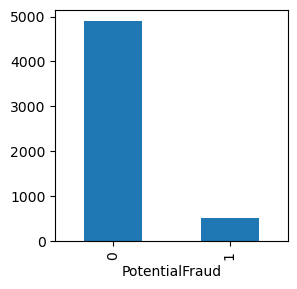

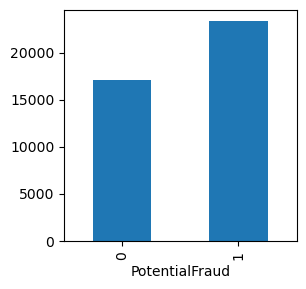

The dataset is approximately balanced at the claim level though us not balanced at the provider level.


In [4]:
# The pattern of PotentialFraud
df_label["PotentialFraud"] = df_label["PotentialFraud"].apply(lambda x: 1 if x=="Yes" else 0)
df_inp["PotentialFraud"] = df_inp["PotentialFraud"].apply(lambda x: 1 if x=="Yes" else 0)

plt.figure(figsize=(3, 3))
df_label.groupby("PotentialFraud").count()["Provider"].plot(kind='bar')
plt.show()

plt.figure(figsize=(3, 3))
df_inp.groupby("PotentialFraud").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation 
print("The dataset is approximately balanced at the claim level though us not balanced at the provider level.")

<Figure size 1000x300 with 0 Axes>

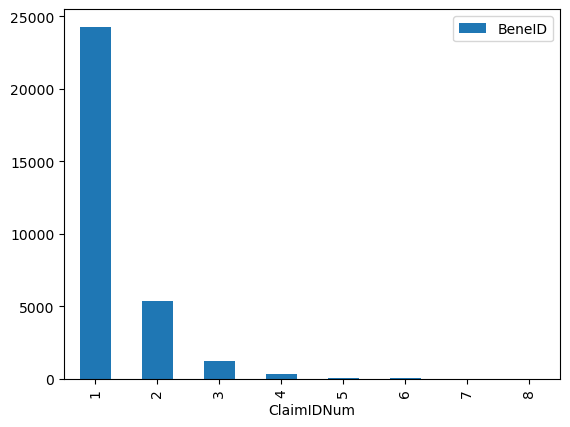

The mean of the number of claims for each BeneID:1.29
The median of the number of claims for each BeneID:1.00
Most beneficiaries have only 1 or 2 claims. As the number of claims per beneficiary increases, the total count of beneficiaries correspondingly decreases.


In [5]:
# The pattern of BeneID
plt.figure(figsize=(10, 3))
df_inp.groupby("BeneID").count()["ClaimID"].reset_index(name = "ClaimIDNum").groupby("ClaimIDNum").count().plot(kind="bar")
plt.show()

# The median and mean of the number of claims for each BeneID
MeanBeneID = df_inp.groupby("BeneID").count()["ClaimID"].mean()
MedianBeneID = df_inp.groupby("BeneID").count()["ClaimID"].median()

# Observation: 
print(f"The mean of the number of claims for each BeneID:{MeanBeneID:.2f}")
print(f"The median of the number of claims for each BeneID:{MedianBeneID:.2f}")
print("Most beneficiaries have only 1 or 2 claims. As the number of claims per beneficiary increases, the total count of beneficiaries correspondingly decreases.")

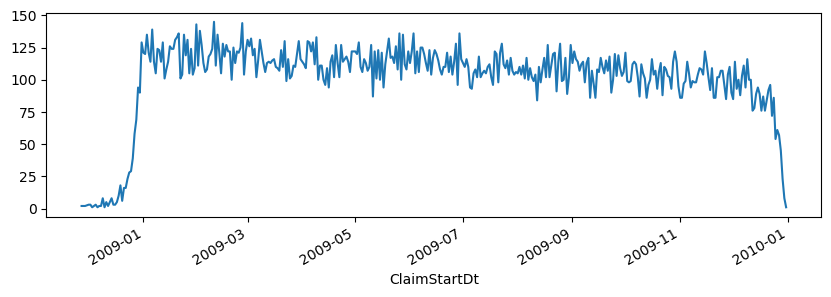

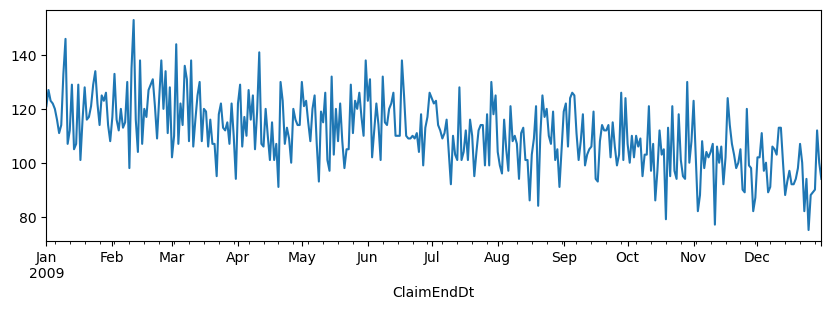

There was a slight decrease in the number of claims throughout 2009.


In [6]:
# convert the start date and end date of claims
df_inp["ClaimStartDt"] = pd.to_datetime(df_inp["ClaimStartDt"])
df_inp["ClaimEndDt"] = pd.to_datetime(df_inp["ClaimEndDt"])

# The pattern of ClaimStartDt
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimStartDt").count()["ClaimID"].plot(kind="line")
plt.show()

# The pattern of ClaimEndDt
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimEndDt").count()["ClaimID"].plot(kind="line")
plt.show()

# Observation: 
print("There was a slight decrease in the number of claims throughout 2009.")

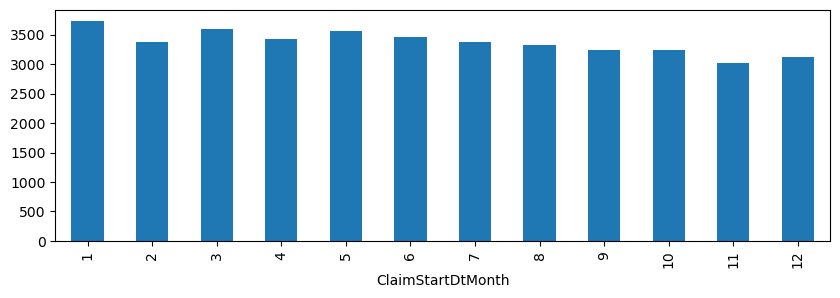

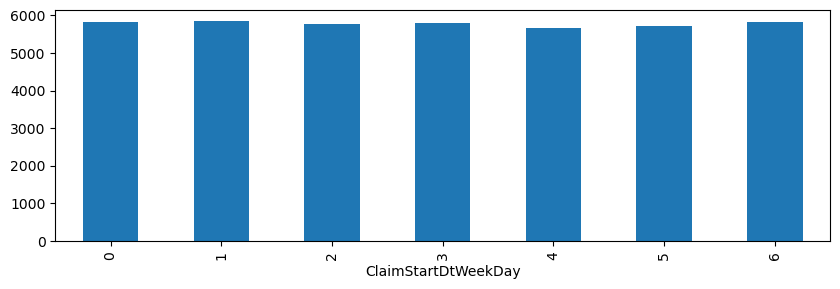

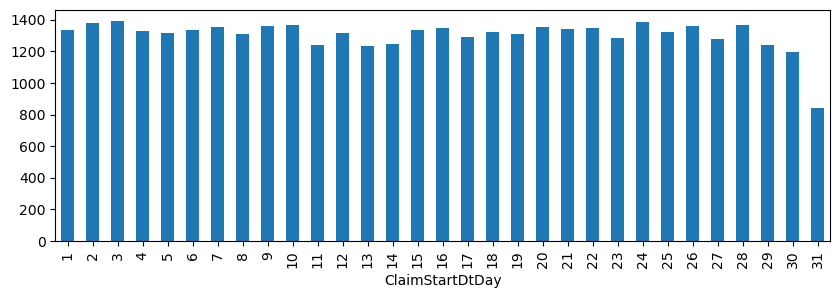

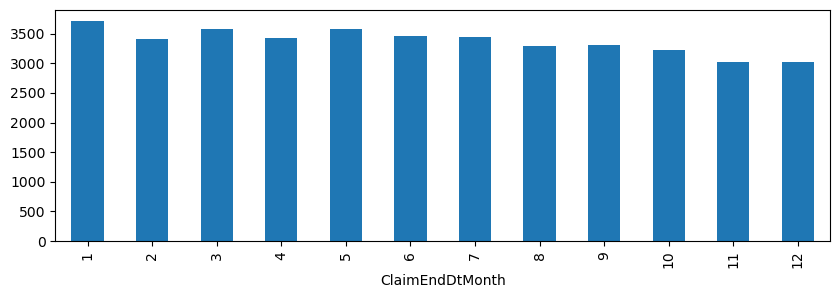

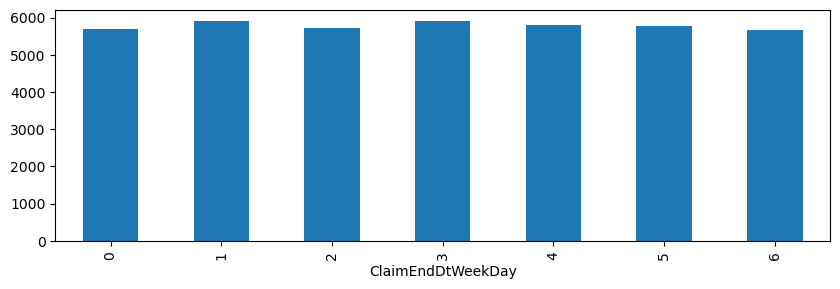

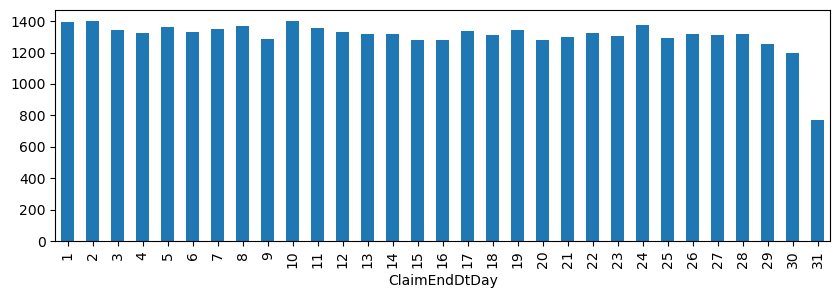

The incidence of insurance claims across various months, weekdays, and individual days remained relatively consistent, with a notable exception on the 31st of each month. This discrepancy is likely attributable to the fact that not all months have a 31st day.


In [7]:
# add new columns
df_inp["ClaimStartDtMonth"]  =  pd.to_datetime(df_inp["ClaimStartDt"]).dt.month
df_inp["ClaimStartDtWeekDay"]  =  pd.to_datetime(df_inp["ClaimStartDt"]).dt.weekday
df_inp["ClaimStartDtDay"]  =  pd.to_datetime(df_inp["ClaimStartDt"]).dt.day

df_inp["ClaimEndDtMonth"]  =  pd.to_datetime(df_inp["ClaimEndDt"]).dt.month
df_inp["ClaimEndDtWeekDay"]  =  pd.to_datetime(df_inp["ClaimEndDt"]).dt.weekday
df_inp["ClaimEndDtDay"]  =  pd.to_datetime(df_inp["ClaimEndDt"]).dt.day

# The pattern of ClaimStartDtMonth
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimStartDtMonth").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimStartDtWeekDay
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimStartDtWeekDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimStartDtDay
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimStartDtDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtMonth
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimEndDtMonth").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtWeekDay
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimEndDtWeekDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtDay
plt.figure(figsize=(10, 3))
df_inp.groupby("ClaimEndDtDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The incidence of insurance claims across various months, weekdays, and individual days remained relatively consistent, with a notable exception on the 31st of each month. This discrepancy is likely attributable to the fact that not all months have a 31st day.")

<Figure size 600x300 with 0 Axes>

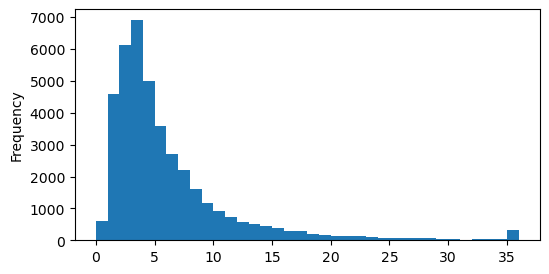

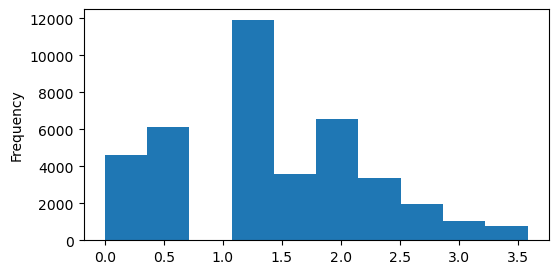

The median of the Claim Duration 4.00
The mean of the Claim Duration 5.66
The claim duration is positively skewed and is also not similar to log-normal distributed.


In [8]:
# add a new column
plt.figure(figsize=(6, 3))
df_inp["ClaimDuration"] = df_inp["ClaimEndDt"] - df_inp["ClaimStartDt"]
df_inp["ClaimDuration"] = df_inp["ClaimDuration"].apply(lambda x:x.days)

# The distribution of ClaimDuration
plt.figure(figsize=(6, 3))
df_inp["ClaimDuration"].plot(kind="hist",bins= int(1 + 3.322 * np.log(nrow)))
plt.show()

plt.figure(figsize=(6, 3))
df_inp[df_inp["ClaimDuration"]>0]["ClaimDuration"].apply(np.log).plot(kind="hist",bins=10)
plt.show()

# The median and mean of the ClaimDuration
MedianClaimDuration = df_inp["ClaimDuration"].median()
MeanClaimDuration = df_inp["ClaimDuration"].mean()

# Observation: 
print(f"The median of the Claim Duration {MedianClaimDuration:.2f}")
print(f"The mean of the Claim Duration {MeanClaimDuration:.2f}")
print(f"The claim duration is positively skewed and is also not similar to log-normal distributed.")

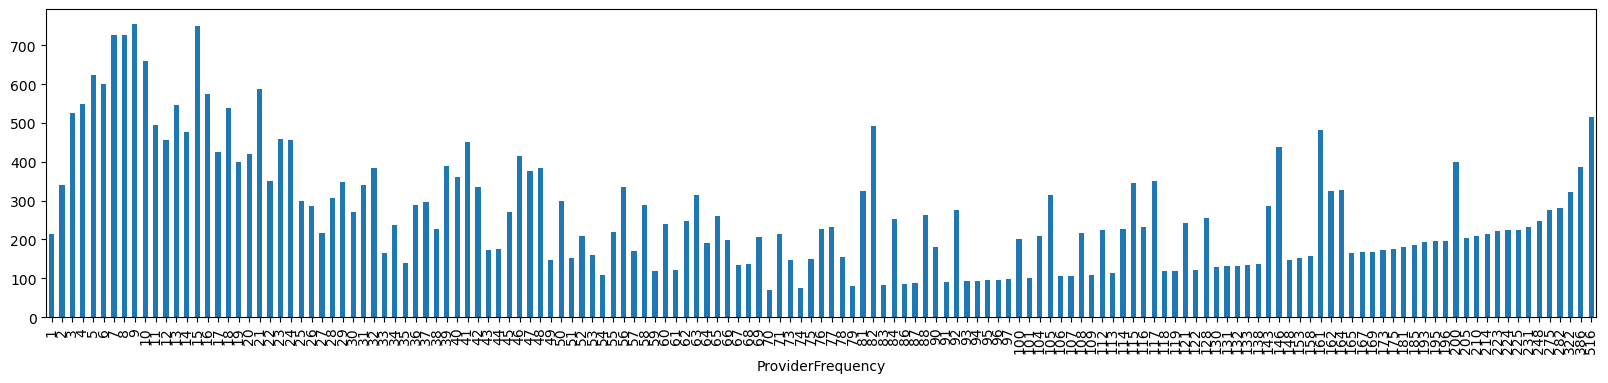

The median of the number of claims for each Provider: 50.00
The mean of the number of claims for each Provider: 82.57
The number of claims across different providers varies and does not follow any known distribution.


In [9]:
# add a new column
ProviderFrequency = df_inp.groupby(["Provider"]).count()["ClaimID"].reset_index()
ProviderFrequency.columns = ["Provider","ProviderFrequency"]
df_inp = pd.merge(df_inp,ProviderFrequency,on="Provider",how="left")

# The distribution of ProviderFrequency
plt.figure(figsize=(20, 4))
df_inp.groupby("ProviderFrequency").count()["ClaimID"].plot(kind="bar")
plt.show()

# The median and mean of the number of claims for provider with the same frequency in the dataset.
MedianProviderFrequency = df_inp["ProviderFrequency"].median()
MeanProviderFrequency = df_inp["ProviderFrequency"].mean()

# Observation: 
print(f"The median of the number of claims for each Provider: {MedianProviderFrequency:.2f}")
print(f"The mean of the number of claims for each Provider: {MeanProviderFrequency:.2f}")
print("The number of claims across different providers varies and does not follow any known distribution.")

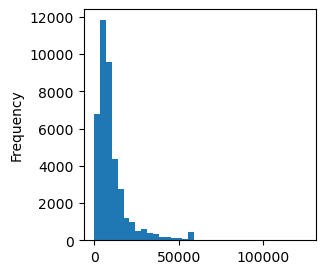

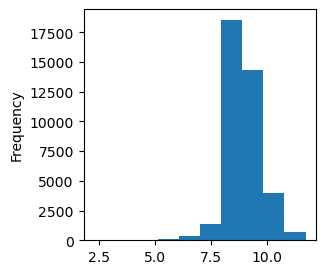

The median of the amount reimbursed by the payer: 7000.00
The mean of the amount reimbursed by the payer: 10087.88
The amount reimbursed by the payer is positive skewed and is closer to log-normal distribution.


In [10]:
# The distribution of InscClaimAmtReimbursed
plt.figure(figsize=(3, 3))
df_inp["InscClaimAmtReimbursed"].plot(kind="hist",bins= int(1 + 3.322 * np.log(nrow)))
plt.show()

plt.figure(figsize=(3, 3))
df_inp[df_inp["InscClaimAmtReimbursed"]>0]["InscClaimAmtReimbursed"].apply(np.log).plot(kind="hist",bins= 10)
plt.show()

# The median and mean of the amount reimbursed by the payer
MedianInscClaimAmtReimbursed = df_inp["InscClaimAmtReimbursed"].median()
MeanInscClaimAmtReimbursed = df_inp["InscClaimAmtReimbursed"].mean()

# Observation: 
print(f"The median of the amount reimbursed by the payer: {MedianInscClaimAmtReimbursed:.2f}")
print(f"The mean of the amount reimbursed by the payer: {MeanInscClaimAmtReimbursed:.2f}")
print("The amount reimbursed by the payer is positive skewed and is closer to log-normal distribution.")

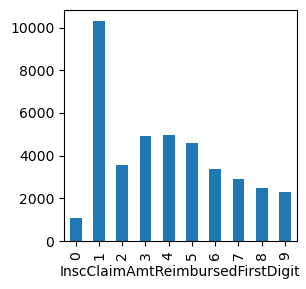

the first digit approximately follows the benford's law except the number of '2'


In [11]:
# add a new column
df_inp["InscClaimAmtReimbursedFirstDigit"] = df_inp["InscClaimAmtReimbursed"].apply(lambda x: str(x)[0])

# The pattern of the first digit of Insurance Claim Amount Reimbursed
plt.figure(figsize=(3, 3))
df_inp.groupby("InscClaimAmtReimbursedFirstDigit").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation: 
print("the first digit approximately follows the benford's law except the number of '2'")

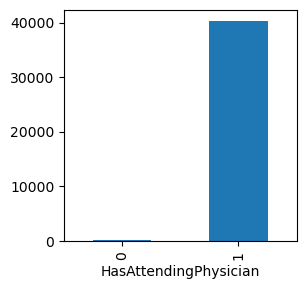

Most inpatient claims have the Attending Physicians


In [12]:
# add a new column
df_inp["HasAttendingPhysician"] = df_inp["AttendingPhysician"].notna().astype(int)

# The pattern of Attending Physician
plt.figure(figsize=(3, 3))
df_inp.groupby("HasAttendingPhysician").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation: 
print("Most inpatient claims have the Attending Physicians")

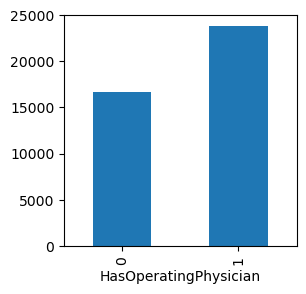

Less than half of the claims don't have the Operating Physicians, implying they don't need operations


In [13]:
# add a new column
df_inp["HasOperatingPhysician"] = df_inp["OperatingPhysician"].notna().astype(int)

# The pattern of Operating Physician
plt.figure(figsize=(3, 3))
df_inp.groupby("HasOperatingPhysician").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation: 
print("Less than half of the claims don't have the Operating Physicians, implying they don't need operations")

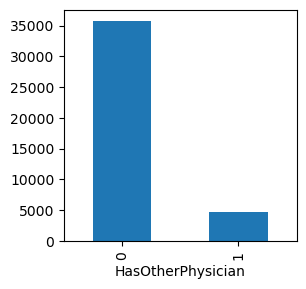

Only a few claims have other Physicians.


In [14]:
# add a new column
df_inp["HasOtherPhysician"] = df_inp["OtherPhysician"].notna().astype(int)

# The pattern of Other Physician
plt.figure(figsize=(3, 3))
df_inp.groupby("HasOtherPhysician").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation: 
print("Only a few claims have other Physicians.")

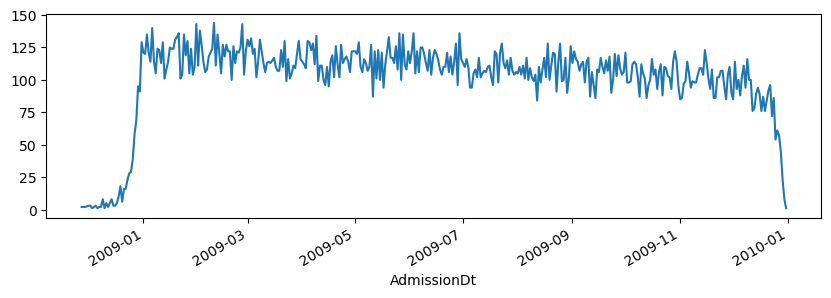

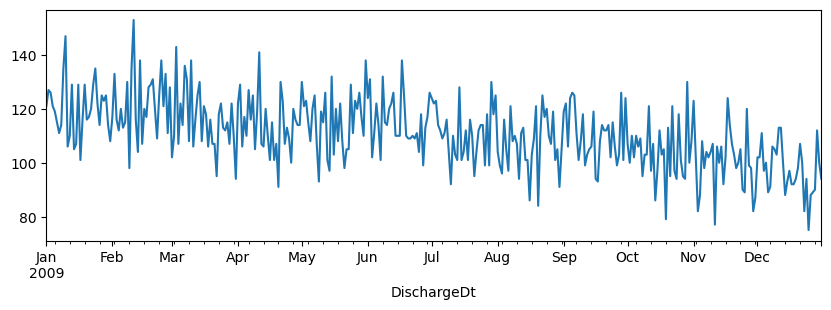

AdmissionDt and DischargeDt shows similar trends to ClaimStartDt and ClaimEndDt


In [15]:
# convert the admission date of claims
df_inp["AdmissionDt"] = pd.to_datetime(df_inp["AdmissionDt"])
df_inp["DischargeDt"] = pd.to_datetime(df_inp["DischargeDt"])

# The pattern of AdmissionDt
plt.figure(figsize=(10, 3))
df_inp.groupby("AdmissionDt").count()["ClaimID"].plot(kind="line")
plt.show()

# The pattern of DischargeDt
plt.figure(figsize=(10, 3))
df_inp.groupby("DischargeDt").count()["ClaimID"].plot(kind="line")
plt.show()

# Observation: 
print("AdmissionDt and DischargeDt shows similar trends to ClaimStartDt and ClaimEndDt")

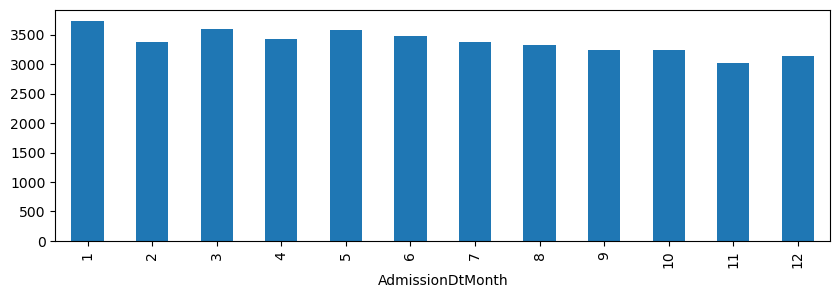

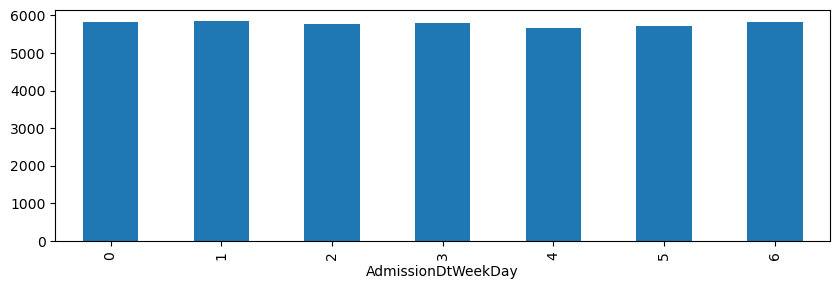

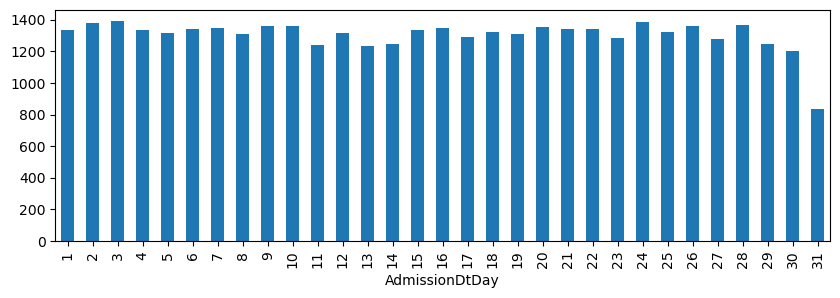

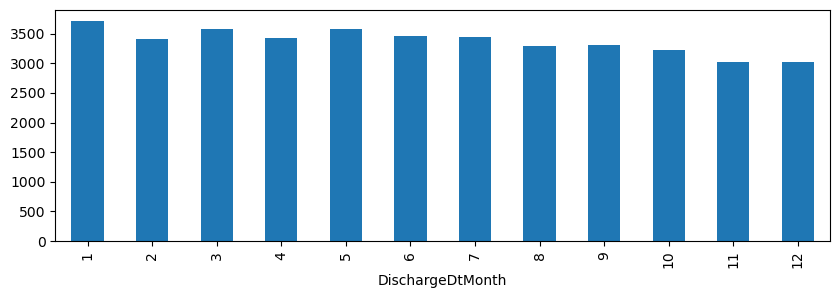

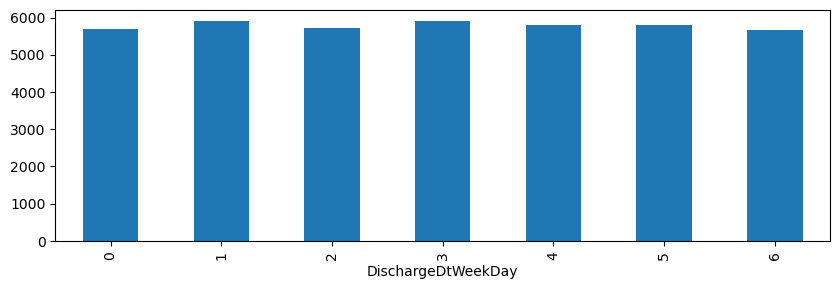

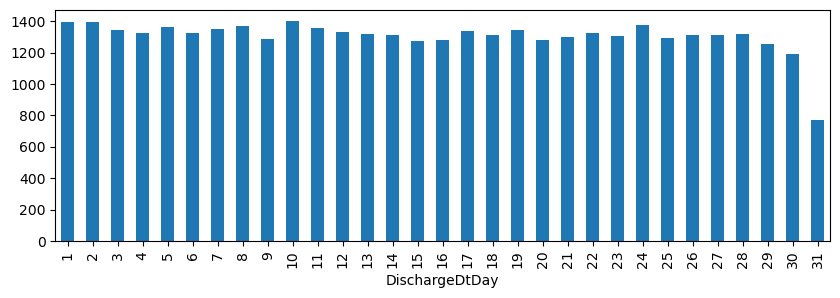

The incidence of admissions and discharges across various months, weekdays, and individual days remained relatively consistent, with a notable exception on the 31st of each month. This discrepancy is likely attributable to the fact that not all months have a 31st day.


In [16]:
# add new columns
df_inp["AdmissionDtMonth"]  =  pd.to_datetime(df_inp["AdmissionDt"]).dt.month
df_inp["AdmissionDtWeekDay"]  =  pd.to_datetime(df_inp["AdmissionDt"]).dt.weekday
df_inp["AdmissionDtDay"]  =  pd.to_datetime(df_inp["AdmissionDt"]).dt.day

df_inp["DischargeDtMonth"]  =  pd.to_datetime(df_inp["DischargeDt"]).dt.month
df_inp["DischargeDtWeekDay"]  =  pd.to_datetime(df_inp["DischargeDt"]).dt.weekday
df_inp["DischargeDtDay"]  =  pd.to_datetime(df_inp["DischargeDt"]).dt.day

# The pattern of ClaimStartDtMonth
plt.figure(figsize=(10, 3))
df_inp.groupby("AdmissionDtMonth").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimStartDtWeekDay
plt.figure(figsize=(10, 3))
df_inp.groupby("AdmissionDtWeekDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimStartDtDay
plt.figure(figsize=(10, 3))
df_inp.groupby("AdmissionDtDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtMonth
plt.figure(figsize=(10, 3))
df_inp.groupby("DischargeDtMonth").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtWeekDay
plt.figure(figsize=(10, 3))
df_inp.groupby("DischargeDtWeekDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# The pattern of ClaimEndDtDay
plt.figure(figsize=(10, 3))
df_inp.groupby("DischargeDtDay").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The incidence of admissions and discharges across various months, weekdays, and individual days remained relatively consistent, with a notable exception on the 31st of each month. This discrepancy is likely attributable to the fact that not all months have a 31st day.")

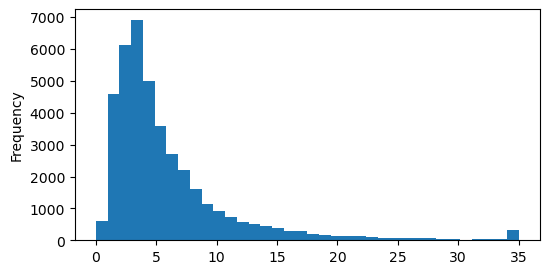

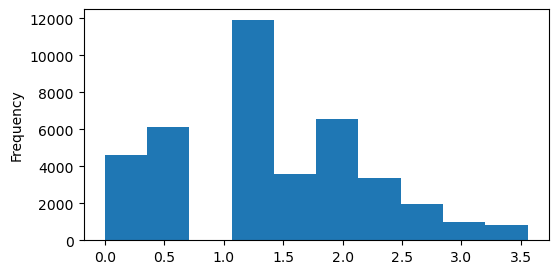

The median of the Hospital Stay Duration 4.00
The mean of the Hospital Stay Duration 5.67
the hospital stay duration is positively skewed and is also not similar to log-normal distributed.


In [17]:
# add a new column
df_inp["HospitalStayDuration"] = df_inp["DischargeDt"] - df_inp["AdmissionDt"]
df_inp["HospitalStayDuration"] = df_inp["HospitalStayDuration"].apply(lambda x:x.days)

# The distribution of HospitalStayDuration
plt.figure(figsize=(6, 3))
df_inp["HospitalStayDuration"].plot(kind="hist",bins = int(1 + 3.322 * np.log(nrow)))
plt.show()

plt.figure(figsize=(6, 3))
df_inp[df_inp["HospitalStayDuration"]>0]["HospitalStayDuration"].apply(np.log).plot(kind="hist",bins= 10)
plt.show()

# The median and mean of the Hospital Stay Duration
MedianHospitalStayDuration = df_inp["HospitalStayDuration"].median()
MeanHospitalStayDuration = df_inp["HospitalStayDuration"].mean()

# Observation: 
print(f"The median of the Hospital Stay Duration {MedianHospitalStayDuration:.2f}")
print(f"The mean of the Hospital Stay Duration {MeanHospitalStayDuration:.2f}")
print("the hospital stay duration is positively skewed and is also not similar to log-normal distributed.")

In [18]:
# add a new column
# sort the discharge date and Admission date for each beneficiary
Bene_count = df_inp.groupby("BeneID").count()["ClaimID"].reset_index()
Bene_count[Bene_count["ClaimID"]>1]["BeneID"]
Bene = df_inp[df_inp["BeneID"].isin(Bene_count[Bene_count["ClaimID"]>1]["BeneID"])]

Bene_ad_rank = Bene.groupby(["BeneID"]).rank()["AdmissionDt"]
Bene_dis_rank = Bene.groupby(["BeneID"]).rank()["DischargeDt"]
Bene_ad = pd.DataFrame({"BeneID":Bene["BeneID"],"AdmissionDt": Bene["AdmissionDt"],"Rank" : Bene_ad_rank})
Bene_dis = pd.DataFrame({"BeneID":Bene["BeneID"],"DischargeDt": Bene["DischargeDt"],"Rank" : Bene_dis_rank})

# calculate the VisitInterval by offset subtraction
Bene_ad["Rank"] = Bene_ad["Rank"] - 1
Bene_ad = Bene_ad[Bene_ad["Rank"]!=0]
Bene_itv = pd.merge(Bene_ad,Bene_dis,on=["BeneID","Rank"],how="inner")
Bene_itv["VisitInterval"] = Bene_itv["AdmissionDt"] - Bene_itv["DischargeDt"]
Bene_itv["VisitInterval"] = Bene_itv["VisitInterval"].apply(lambda x:x.days)
Bene_itv = Bene_itv.drop(["Rank","DischargeDt"],axis=1)

df_inp = pd.merge(df_inp,Bene_itv,on=["BeneID","AdmissionDt"],how="left")

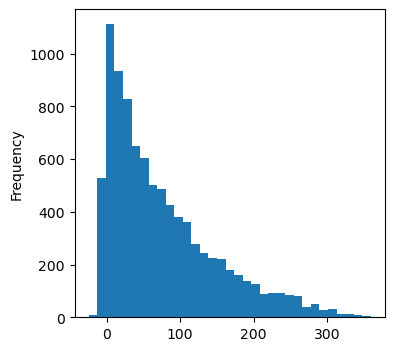

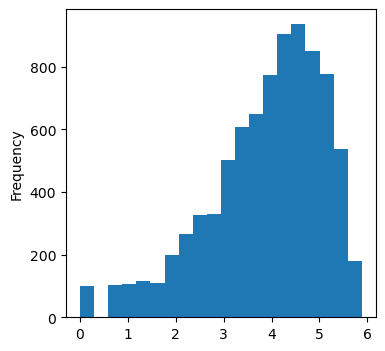

The median of the Visit Interval 54.00
The mean of the Visit Interval 75.59
VisitInterval is positively skewed, but strangely, its log-scale plot is negatively skewed.


In [19]:
# The distribution of Visit Interval for each claim
plt.figure(figsize=(4, 4))
df_inp["VisitInterval"].plot(kind="hist",bins = int(1 + 3.322 * np.log(len(Bene))))
plt.show()

plt.figure(figsize=(4, 4))
df_inp[df_inp["VisitInterval"]>0]["VisitInterval"].apply(np.log).plot(kind="hist",bins = 20)
plt.show()

# The median and mean of the Visit Interval
MedianVisitInterval = df_inp["VisitInterval"].median()
MeanVisitInterval = df_inp["VisitInterval"].mean()

# Observation: 
print(f"The median of the Visit Interval {MedianVisitInterval:.2f}")
print(f"The mean of the Visit Interval {MeanVisitInterval:.2f}")
print("VisitInterval is positively skewed, but strangely, its log-scale plot is negatively skewed.")

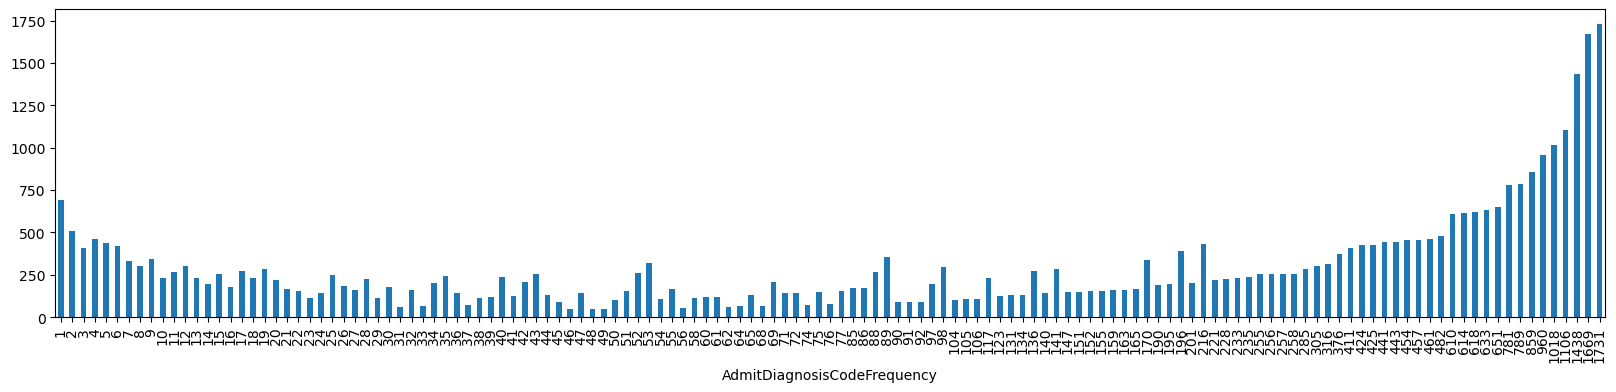

The median of the number of claims for each Admission Diagnosis Code: 233.00
The mean of the number of claims for each Admission Diagnosis Code: 466.28
The number of claims across different Admission Diagnosis Codes varies and does not follow any known distribution.


In [20]:
# add a new column
AdmitDiagnosisCodeFrequency = df_inp.groupby(["ClmAdmitDiagnosisCode"]).count()["ClaimID"].reset_index()
AdmitDiagnosisCodeFrequency.columns = ["ClmAdmitDiagnosisCode","AdmitDiagnosisCodeFrequency"]
df_inp = pd.merge(df_inp,AdmitDiagnosisCodeFrequency,on="ClmAdmitDiagnosisCode",how="left")

# The distribution of AdmitDiagnosisCodeFrequency
plt.figure(figsize=(20, 4))
df_inp.groupby("AdmitDiagnosisCodeFrequency").count()["ClaimID"].plot(kind="bar")
plt.show()

# The median and mean of the number of claims for Admission Diagnosis Code with the same frequency in the dataset.
MedianAdmitDiagnosisCodeFrequency = df_inp["AdmitDiagnosisCodeFrequency"].median()
MeanAdmitDiagnosisCodeFrequency = df_inp["AdmitDiagnosisCodeFrequency"].mean()

# Observation: 
print(f"The median of the number of claims for each Admission Diagnosis Code: {MedianAdmitDiagnosisCodeFrequency:.2f}")
print(f"The mean of the number of claims for each Admission Diagnosis Code: {MeanAdmitDiagnosisCodeFrequency:.2f}")
print("The number of claims across different Admission Diagnosis Codes varies and does not follow any known distribution.")

In [21]:
# add a new column
def CDC_to_TDC(value):

    if pd.isnull(value):
        return "0"

    # purely numeric
    if value[0] not in ("V","E"):
        # get the first three digit of Claim Diagnosis Code
        first_three_digit = int(value[:3])
        if 1<= first_three_digit <= 9: category = "1"
        if 10<= first_three_digit <= 18: category = "2"
        if 20<= first_three_digit <= 27: category = "3"
        if 30<= first_three_digit <= 41: category = "4"
        if 42<= first_three_digit <= 42: category = "5"
        if 45<= first_three_digit <= 49: category = "6"
        if 50<= first_three_digit <= 59: category = "7"
        if 60<= first_three_digit <= 66: category = "8"
        if 70<= first_three_digit <= 79: category = "9"
        if 80<= first_three_digit <= 88: category = "10"
        if 90<= first_three_digit <= 99: category = "11"
        if 100<= first_three_digit <= 104: category = "12"
        if 110<= first_three_digit <= 118: category = "13"
        if 120<= first_three_digit <= 129: category = "14"
        if 130<= first_three_digit <= 136: category = "15"
        if 137<= first_three_digit <= 139: category = "16"
        if 140<= first_three_digit <= 149: category = "17"
        if 150<= first_three_digit <= 159: category = "18"
        if 160<= first_three_digit <= 165: category = "19"
        if 170<= first_three_digit <= 176: category = "20"
        if 179<= first_three_digit <= 189: category = "21"
        if 190<= first_three_digit <= 199: category = "22"
        if 200<= first_three_digit <= 208: category = "23"
        if 209<= first_three_digit <= 209: category = "24"
        if 210<= first_three_digit <= 229: category = "25"
        if 230<= first_three_digit <= 234: category = "26"
        if 235<= first_three_digit <= 238: category = "27"
        if 239<= first_three_digit <= 239: category = "28"
        if 240<= first_three_digit <= 246: category = "29"
        if 249<= first_three_digit <= 259: category = "30"
        if 260<= first_three_digit <= 269: category = "31"
        if 270<= first_three_digit <= 279: category = "32"
        if 280<= first_three_digit <= 289: category = "33"
        if 290<= first_three_digit <= 294: category = "34"
        if 295<= first_three_digit <= 299: category = "35"
        if 300<= first_three_digit <= 316: category = "36"
        if 317<= first_three_digit <= 319: category = "37"
        if 320<= first_three_digit <= 327: category = "38"
        if 330<= first_three_digit <= 337: category = "39"
        if 338<= first_three_digit <= 338: category = "40"
        if 339<= first_three_digit <= 339: category = "41"
        if 340<= first_three_digit <= 349: category = "42"
        if 350<= first_three_digit <= 359: category = "43"
        if 360<= first_three_digit <= 379: category = "44"
        if 380<= first_three_digit <= 389: category = "45"
        if 390<= first_three_digit <= 392: category = "46"
        if 393<= first_three_digit <= 398: category = "47"
        if 401<= first_three_digit <= 405: category = "48"
        if 410<= first_three_digit <= 414: category = "49"
        if 415<= first_three_digit <= 417: category = "50"
        if 420<= first_three_digit <= 429: category = "51"
        if 430<= first_three_digit <= 438: category = "52"
        if 440<= first_three_digit <= 449: category = "53"
        if 451<= first_three_digit <= 459: category = "54"
        if 460<= first_three_digit <= 466: category = "55"
        if 470<= first_three_digit <= 478: category = "56"
        if 480<= first_three_digit <= 488: category = "57"
        if 490<= first_three_digit <= 496: category = "58"
        if 500<= first_three_digit <= 508: category = "59"
        if 510<= first_three_digit <= 519: category = "60"
        if 520<= first_three_digit <= 529: category = "61"
        if 530<= first_three_digit <= 539: category = "62"
        if 540<= first_three_digit <= 543: category = "63"
        if 550<= first_three_digit <= 553: category = "64"
        if 555<= first_three_digit <= 558: category = "65"
        if 560<= first_three_digit <= 569: category = "66"
        if 570<= first_three_digit <= 579: category = "67"
        if 580<= first_three_digit <= 589: category = "68"
        if 590<= first_three_digit <= 599: category = "69"
        if 600<= first_three_digit <= 608: category = "70"
        if 610<= first_three_digit <= 611: category = "71"
        if 614<= first_three_digit <= 616: category = "72"
        if 617<= first_three_digit <= 629: category = "73"
        if 630<= first_three_digit <= 639: category = "74"
        if 640<= first_three_digit <= 649: category = "75"
        if 650<= first_three_digit <= 659: category = "76"
        if 660<= first_three_digit <= 669: category = "77"
        if 670<= first_three_digit <= 677: category = "78"
        if 678<= first_three_digit <= 679: category = "79"
        if 680<= first_three_digit <= 686: category = "80"
        if 690<= first_three_digit <= 698: category = "81"
        if 700<= first_three_digit <= 709: category = "82"
        if 710<= first_three_digit <= 719: category = "83"
        if 720<= first_three_digit <= 724: category = "84"
        if 725<= first_three_digit <= 729: category = "85"
        if 730<= first_three_digit <= 739: category = "86"
        if 740<= first_three_digit <= 759: category = "87"
        if 760<= first_three_digit <= 763: category = "88"
        if 764<= first_three_digit <= 779: category = "89"
        if 780<= first_three_digit <= 789: category = "90"
        if 790<= first_three_digit <= 796: category = "91"
        if 797<= first_three_digit <= 799: category = "92"
        if 800<= first_three_digit <= 804: category = "93"
        if 805<= first_three_digit <= 809: category = "94"
        if 810<= first_three_digit <= 819: category = "95"
        if 820<= first_three_digit <= 829: category = "96"
        if 830<= first_three_digit <= 839: category = "97"
        if 840<= first_three_digit <= 848: category = "98"
        if 850<= first_three_digit <= 854: category = "99"
        if 860<= first_three_digit <= 869: category = "100"
        if 870<= first_three_digit <= 879: category = "101"
        if 880<= first_three_digit <= 887: category = "102"
        if 890<= first_three_digit <= 897: category = "103"
        if 900<= first_three_digit <= 904: category = "104"
        if 905<= first_three_digit <= 909: category = "105"
        if 910<= first_three_digit <= 919: category = "106"
        if 920<= first_three_digit <= 924: category = "107"
        if 925<= first_three_digit <= 929: category = "108"
        if 930<= first_three_digit <= 939: category = "109"
        if 940<= first_three_digit <= 949: category = "110"
        if 950<= first_three_digit <= 957: category = "111"
        if 958<= first_three_digit <= 959: category = "112"
        if 960<= first_three_digit <= 979: category = "113"
        if 980<= first_three_digit <= 989: category = "114"
        if 990<= first_three_digit <= 995: category = "115"
        if 996<= first_three_digit <= 999: category = "116"

    # code beginning with E  
    elif value[0] == "E":
        # get the first three digit of Claim Diagnosis Code
        first_three_digit = int(value[1:4])
        if 0<= first_three_digit <= 0: category = "133"
        if 1<= first_three_digit <= 30: category = "134"
        if 800<= first_three_digit <= 807: category = "135"
        if 810<= first_three_digit <= 819: category = "136"
        if 820<= first_three_digit <= 825: category = "137"
        if 826<= first_three_digit <= 829: category = "138"
        if 830<= first_three_digit <= 838: category = "139"
        if 840<= first_three_digit <= 845: category = "140"
        if 846<= first_three_digit <= 849: category = "141"
        if 850<= first_three_digit <= 858: category = "142"
        if 860<= first_three_digit <= 869: category = "143"
        if 870<= first_three_digit <= 876: category = "144"
        if 878<= first_three_digit <= 879: category = "145"
        if 880<= first_three_digit <= 888: category = "146"
        if 890<= first_three_digit <= 899: category = "147"
        if 900<= first_three_digit <= 909: category = "148"
        if 910<= first_three_digit <= 915: category = "149"
        if 916<= first_three_digit <= 928: category = "150"
        if 929<= first_three_digit <= 929: category = "151"
        if 930<= first_three_digit <= 949: category = "152"
        if 950<= first_three_digit <= 959: category = "153"
        if 960<= first_three_digit <= 969: category = "154"
        if 970<= first_three_digit <= 978: category = "155"
        if 980<= first_three_digit <= 989: category = "156"
        if 990<= first_three_digit <= 999: category = "157"

    # code beginning with V
    elif value[0] == "V":
        # get the first two digit of Claim Diagnosis Code
        first_two_digit = int(value[1:3])
        if 1 <= first_two_digit <= 9: category = "117"
        if 10 <= first_two_digit <= 19: category = "118"
        if 20 <= first_two_digit <= 29: category = "119"
        if 30 <= first_two_digit <= 39: category = "120"
        if 40 <= first_two_digit <= 49: category = "121"
        if 50 <= first_two_digit <= 59: category = "122"
        if 60 <= first_two_digit <= 69: category = "123"
        if 70 <= first_two_digit <= 82: category = "124"
        if 83 <= first_two_digit <= 84: category = "125"
        if 85 <= first_two_digit <= 85: category = "126"
        if 86 <= first_two_digit <= 86: category = "127"
        if 87 <= first_two_digit <= 87: category = "128"
        if 88 <= first_two_digit <= 88: category = "129"
        if 89 <= first_two_digit <= 89: category = "130"
        if 90 <= first_two_digit <= 90: category = "131"
        if 91 <= first_two_digit <= 91: category = "132"

    return category

df_inp["AdmitDiagnosticCategory"] = df_inp["ClmAdmitDiagnosisCode"].apply(CDC_to_TDC)

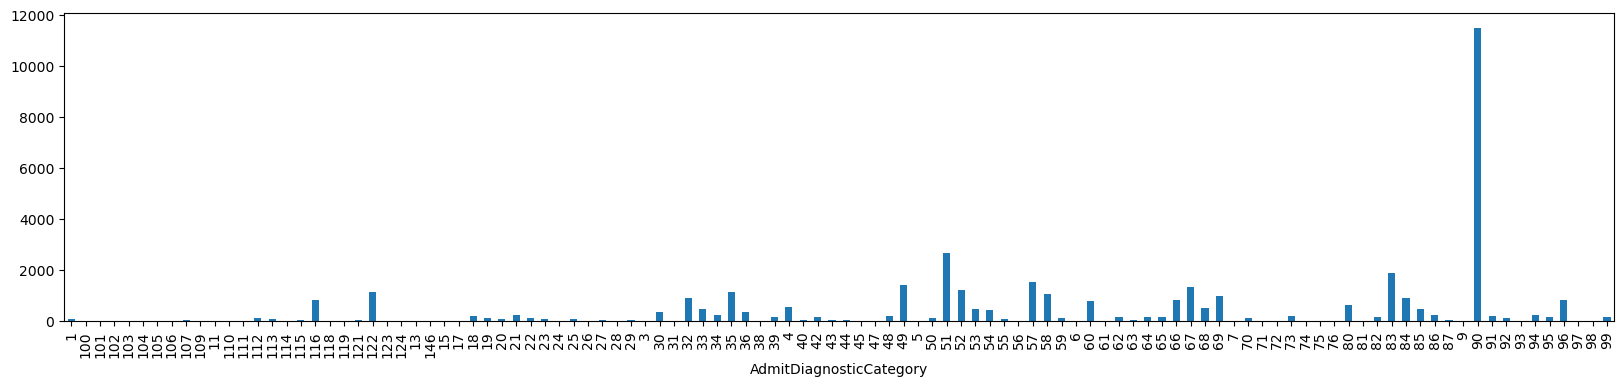

The number of claims across different Admit Diagnostic Category varies, but the category 90 has the much more claims than other categories.


In [22]:
# The pattern of AdmitDiagnosticCategory
plt.figure(figsize=(20, 4))
df_inp.groupby("AdmitDiagnosticCategory").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims across different Admit Diagnostic Category varies, but the category 90 has the much more claims than other categories.")

In [23]:
# add a new column
def DRG_to_MDC(value):
    if value == "OTH":
        return "99"
    elif 1 <= int(value) <= 17:
        return "0"
    elif 20 <= int(value) <= 103:
        return "1"
    elif 113 <= int(value) <= 125:
        return "2"
    elif 129 <= int(value) <= 159:
        return "3"
    elif 163 <= int(value) <= 208:
        return "4"
    elif 215 <= int(value) <= 316:
        return "5"
    elif 326 <= int(value) <= 395:
        return "6"
    elif 405 <= int(value) <= 446:
        return "7"
    elif 453 <= int(value) <= 566:
        return "8"
    elif 573 <= int(value) <= 607:
        return "9"
    elif 614 <= int(value) <= 645:
        return "10"
    elif 652 <= int(value) <= 700:
        return "11"
    elif 707 <= int(value) <= 730:
        return "12"
    elif 734 <= int(value) <= 761:
        return "13"
    elif 765 <= int(value) <= 782:
        return "14"
    elif 789 <= int(value) <= 795:
        return "15"
    elif 799 <= int(value) <= 816:
        return "16"
    elif 820 <= int(value) <= 849:
        return "17"
    elif 853 <= int(value) <= 872:
        return "18"
    elif 876 <= int(value) <= 887:
        return "19"
    elif 894 <= int(value) <= 897:
        return "20"
    elif 901 <= int(value) <= 923:
        return "21"
    elif 927 <= int(value) <= 935:
        return "22"
    elif 939 <= int(value) <= 951:
        return "23"
    elif 955 <= int(value) <= 965:
        return "24"
    elif 969 <= int(value) <= 977:
        return "25"
    elif 981 <= int(value) <= 999:
        return "26"
    
df_inp["MajorDiagnosticCategory"] = df_inp["DiagnosisGroupCode"].apply(DRG_to_MDC)

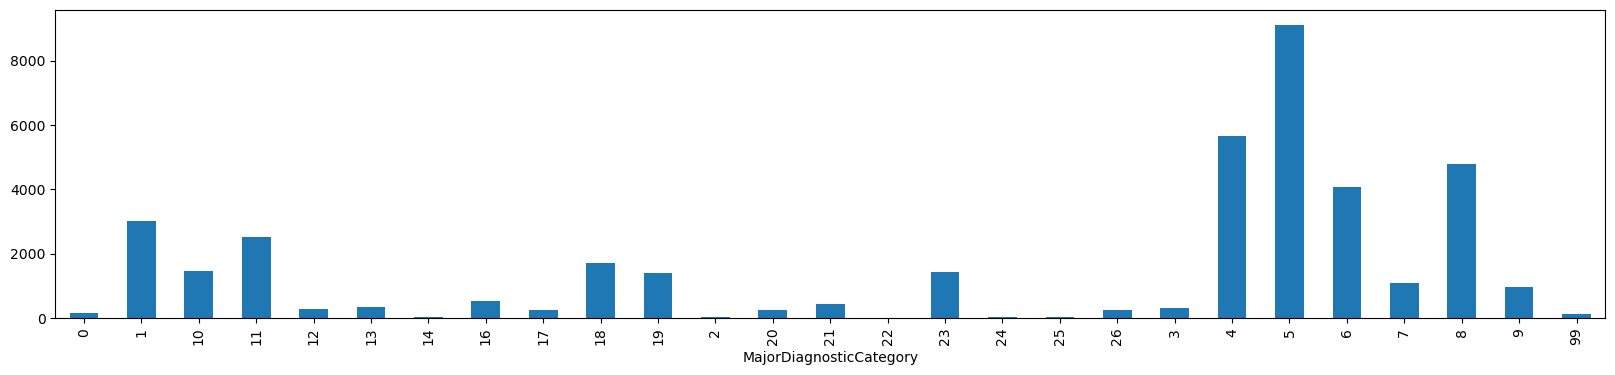

The number of claims across different Major Diagnostic Category varies, but the categories of 4, 5, 6, and 8 have the much more claims than other categories.


In [24]:
# The pattern of AdmitDiagnosticCategory
plt.figure(figsize=(20, 4))
df_inp.groupby("MajorDiagnosticCategory").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims across different Major Diagnostic Category varies, but the categories of 4, 5, 6, and 8 have the much more claims than other categories.")

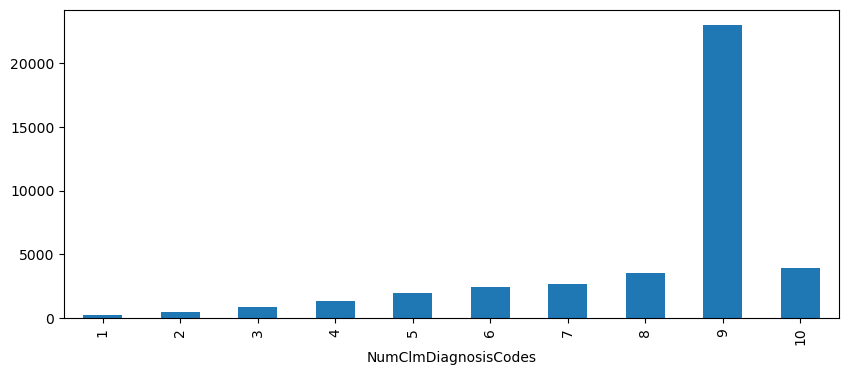

The median of the number of Admit Diagnosis Codes for each claim: 9.00
The mean of the number of Admit Diagnosis Codes for each claim: 8.09
Most claims have 9 Claim Diagnosis Codes.


In [25]:
# add a new column
df_inp["NumClmDiagnosisCodes"] = \
df_inp["ClmDiagnosisCode_1"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_2"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_3"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_4"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_5"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_6"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_7"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_8"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_9"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmDiagnosisCode_10"].apply(lambda x:1 if pd.notnull(x) else 0)

# The distribution of NumClmDiagnosisCodes
plt.figure(figsize=(10, 4))
df_inp.groupby("NumClmDiagnosisCodes").count()["ClaimID"].plot(kind="bar")
plt.show()

# The median and mean of the number of Admit Diagnosis Codes for claim
MedianNumClmDiagnosisCodes = df_inp["NumClmDiagnosisCodes"].median()
MeanNumClmDiagnosisCodes = df_inp["NumClmDiagnosisCodes"].mean()

# Observation: 
print(f"The median of the number of Admit Diagnosis Codes for each claim: {MedianNumClmDiagnosisCodes:.2f}")
print(f"The mean of the number of Admit Diagnosis Codes for each claim: {MeanNumClmDiagnosisCodes:.2f}")
print("Most claims have 9 Claim Diagnosis Codes.")

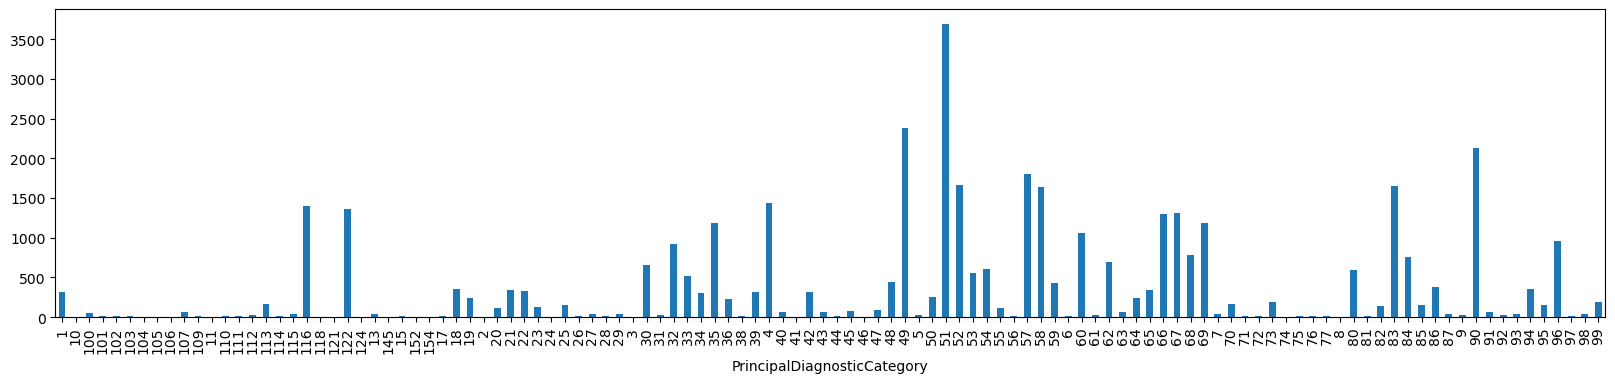

The number of claims across different Principal Diagnostic Category varies.


In [26]:
# add a new column
df_inp["PrincipalDiagnosticCategory"] = df_inp["ClmDiagnosisCode_1"].apply(CDC_to_TDC)

# The pattern of PrincipalDiagnosticCategory
plt.figure(figsize=(20, 4))
df_inp.groupby("PrincipalDiagnosticCategory").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims across different Principal Diagnostic Category varies.")

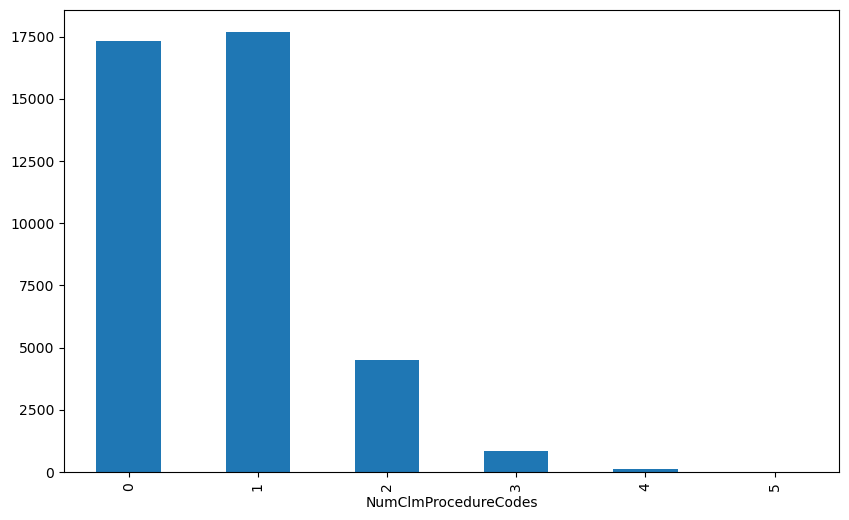

Most claims have at most 1 ProcedureCode.


In [27]:
# add a new column
df_inp["NumClmProcedureCodes"] = \
df_inp["ClmProcedureCode_1"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmProcedureCode_2"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmProcedureCode_3"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmProcedureCode_4"].apply(lambda x:1 if pd.notnull(x) else 0) + \
df_inp["ClmProcedureCode_5"].apply(lambda x:1 if pd.notnull(x) else 0)

# The distribution of NumClmProcedureCodes
plt.figure(figsize=(10, 6))
df_inp.groupby("NumClmProcedureCodes").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("Most claims have at most 1 ProcedureCode.")

In [28]:
# Analysis of ClmProcedureCode columns
print(df_inp[df_inp["ClaimID"]=="CLM38412"][["ClaimID","ClmAdmitDiagnosisCode","DiagnosisGroupCode","ClmDiagnosisCode_1","ClmProcedureCode_1"]])
print()
print(df_inp["ClmProcedureCode_1"].dtype)
print()
# DiagnosisGroupCode: 067 - Diseases and Disorders of the Nervous System
# ClmAdmitDiagnosisCode: 431 - Intracerebral hemorrhage
# ClmDiagnosisCode_1: 43491 - Cerebral artery occlusion, unspecified with cerebral infarction
# ClmProcedureCode_1: 331 - Incision of lung
# ClmProcedureCode_1*: 0331 - Spinal tap

# Observation:
print("Our case study of claim CLM38412 revealed a procedural discrepancy. The beneficiary was assigned procedure code '331 - Incision of lung' instead of the correct '0331 - Spinal tap'. This error highlights a critical issue: the representation of Claim Procedure Codes should be as strings, not numerical values. This is because some codes begin with '0', which is significant.This format discrepancy particularly affects codes under 1000, which have less than four digits and might include leading or trailing zeros.")
print("ClmProcedureCode_1 with less than 3 digit:",len(df_inp[df_inp["ClmProcedureCode_1"]<1000]["ClmProcedureCode_1"]))
print("Fortunately, this issue impacts only a small portion of the data set. Therefore, we can still leverage the classification of claim procedure definitions to create a new feature for grouping claim procedure codes to 18 categories.")

    ClaimID ClmAdmitDiagnosisCode DiagnosisGroupCode ClmDiagnosisCode_1  \
3  CLM38412                   431                067              43491   

   ClmProcedureCode_1  
3               331.0  

float64

Our case study of claim CLM38412 revealed a procedural discrepancy. The beneficiary was assigned procedure code '331 - Incision of lung' instead of the correct '0331 - Spinal tap'. This error highlights a critical issue: the representation of Claim Procedure Codes should be as strings, not numerical values. This is because some codes begin with '0', which is significant.This format discrepancy particularly affects codes under 1000, which have less than four digits and might include leading or trailing zeros.
ClmProcedureCode_1 with less than 3 digit: 2585
Fortunately, this issue impacts only a small portion of the data set. Therefore, we can still leverage the classification of claim procedure definitions to create a new feature for grouping claim procedure codes to 18 categories.

In [29]:
# add a new column
def CPC_to_PPC(value):
    # handle the missing values
    if pd.isnull(value):
        return "99"

    # the Claim Procedure Code less than 100 must start with "00"
    if value < 100:
        return "0"

    # get the first two digits of Claim Procedure Code
    first_two_digit = int(str(value)[:2])
    if 1 <= first_two_digit <= 5: category = "1"
    if 6 <= first_two_digit <= 7: category = "2"
    if 8 <= first_two_digit <= 16: category = "3"
    if 17 <= first_two_digit <= 17: category = "3A"
    if 18 <= first_two_digit <= 20: category = "4"
    if 21 <= first_two_digit <= 29: category = "5"
    if 30 <= first_two_digit <= 34: category = "6"
    if 35 <= first_two_digit <= 39: category = "7"
    if 40 <= first_two_digit <= 41: category = "8"
    if 42 <= first_two_digit <= 54: category = "9"
    if 55 <= first_two_digit <= 59: category = "10"
    if 60 <= first_two_digit <= 64: category = "11"
    if 65 <= first_two_digit <= 71: category = "12"
    if 72 <= first_two_digit <= 75: category = "13"
    if 76 <= first_two_digit <= 84: category = "14"
    if 85 <= first_two_digit <= 86: category = "15"
    if 87 <= first_two_digit <= 99: category = "16"
        
    return category

df_inp["PrincipalProcedureCategory"] = df_inp["ClmProcedureCode_1"].apply(CPC_to_PPC)

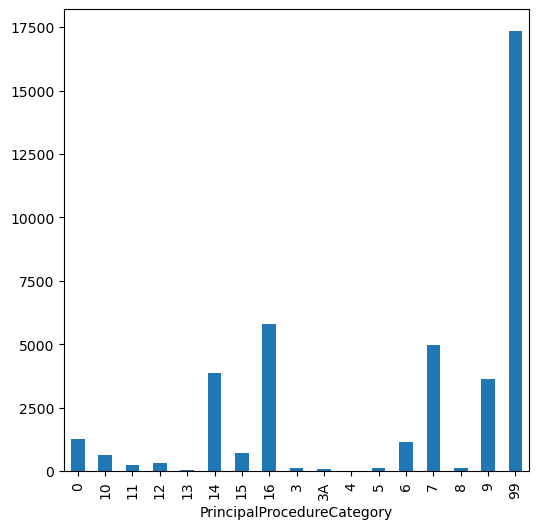

Most claims has the Principal Procedure Category of 99, indicating they do not have Principal Procedure


In [30]:
# The pattern of PrincipalProcedureCategory
plt.figure(figsize=(6, 6))
df_inp.groupby("PrincipalProcedureCategory").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("Most claims has the Principal Procedure Category of 99, indicating they do not have Principal Procedure")

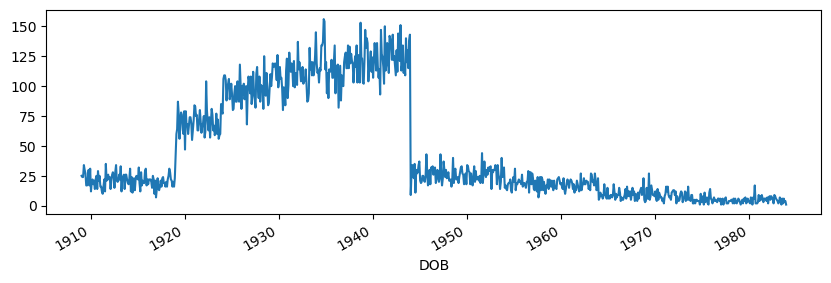

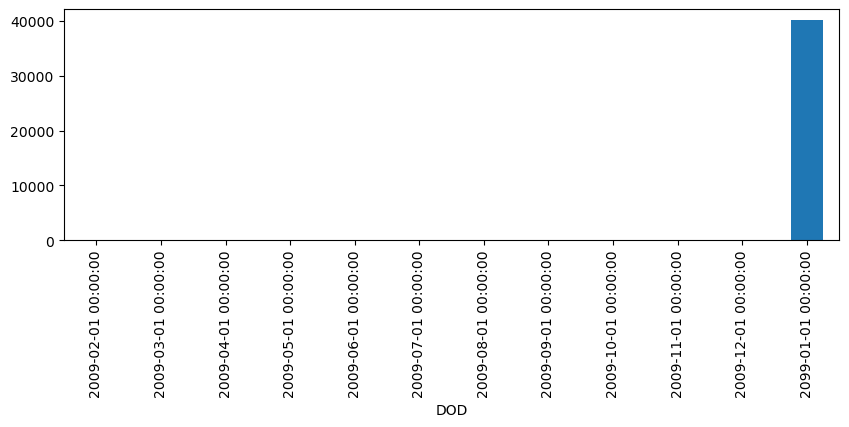

Most claims are from beneficiaries who are born before year 1945.
Most claims are from beneficiaries who are still alive.


In [31]:
# convert the DOB and DOD of claims
df_inp["DOB"] = pd.to_datetime(df_inp["DOB"])
df_inp["DOD"] = pd.to_datetime(df_inp["DOD"])
df_inp["DOD"] = df_inp["DOD"].apply(lambda x: pd.to_datetime("2099-1-1") if pd.isnull(x) else x)

# The distribution of DOB
plt.figure(figsize=(10, 3))
df_inp.groupby("DOB").count()["ClaimID"].plot(kind="line")
plt.show()

# The distribution of DOD
plt.figure(figsize=(10, 3))
df_inp.groupby("DOD").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation: 
print("Most claims are from beneficiaries who are born before year 1945.")
print("Most claims are from beneficiaries who are still alive.")

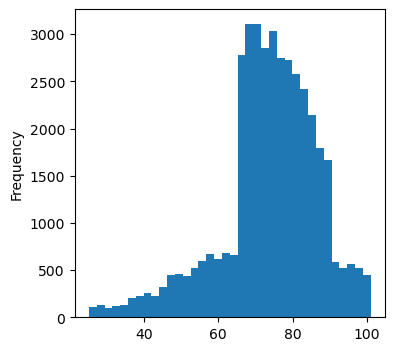

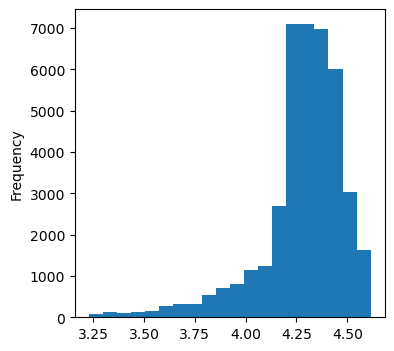

The median of the Age 74.69
The mean of the Age 73.63
Age distribution is not symmetric and shows a concentration of values on the right side the 65 mark.


In [32]:
# add a new column
df_inp["Age"] = df_inp["ClaimStartDt"] - df_inp["DOB"]
df_inp["Age"] = df_inp["Age"].apply(lambda x:x.days/365.25)

# The distribution of Age
plt.figure(figsize=(4, 4))
df_inp["Age"].plot(kind="hist",bins = int(1 + 3.322 * np.log(len(df_inp["Age"]))))
plt.show()

plt.figure(figsize=(4, 4))
df_inp[df_inp["Age"]>0]["Age"].apply(np.log).plot(kind="hist",bins = 20)
plt.show()

# The median and mean of the Age
MedianAge = df_inp["Age"].median()
MeanAge = df_inp["Age"].mean()

# Observation: 
print(f"The median of the Age {MedianAge:.2f}")
print(f"The mean of the Age {MeanAge:.2f}")
print("Age distribution is not symmetric and shows a concentration of values on the right side the 65 mark.")

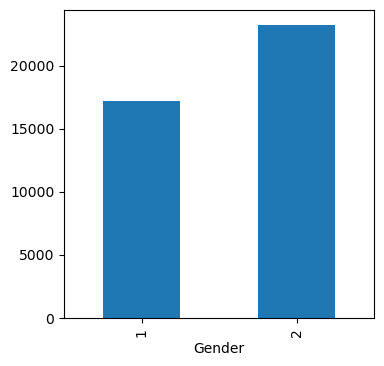

The number of claims for gender 2 is slightly more than the ones for gender 1.


In [33]:
# The pattern of Gender
plt.figure(figsize=(4, 4))
df_inp.groupby("Gender").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims for gender 2 is slightly more than the ones for gender 1.")

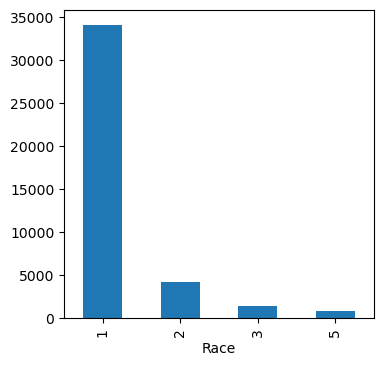

The number of claims for race 1 is much more than the others.


In [34]:
# The pattern of Race
plt.figure(figsize=(4, 4))
df_inp.groupby("Race").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims for race 1 is much more than the others.")

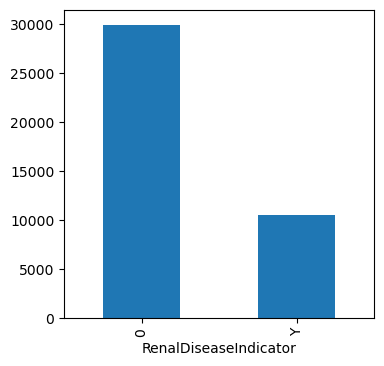

There are around 3/4 claims where beneficiaries did not have the renal disease.


In [35]:
# The pattern of RenalDiseaseIndicator
plt.figure(figsize=(4, 4))
df_inp.groupby("RenalDiseaseIndicator").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("There are around 3/4 claims where beneficiaries did not have the renal disease.")

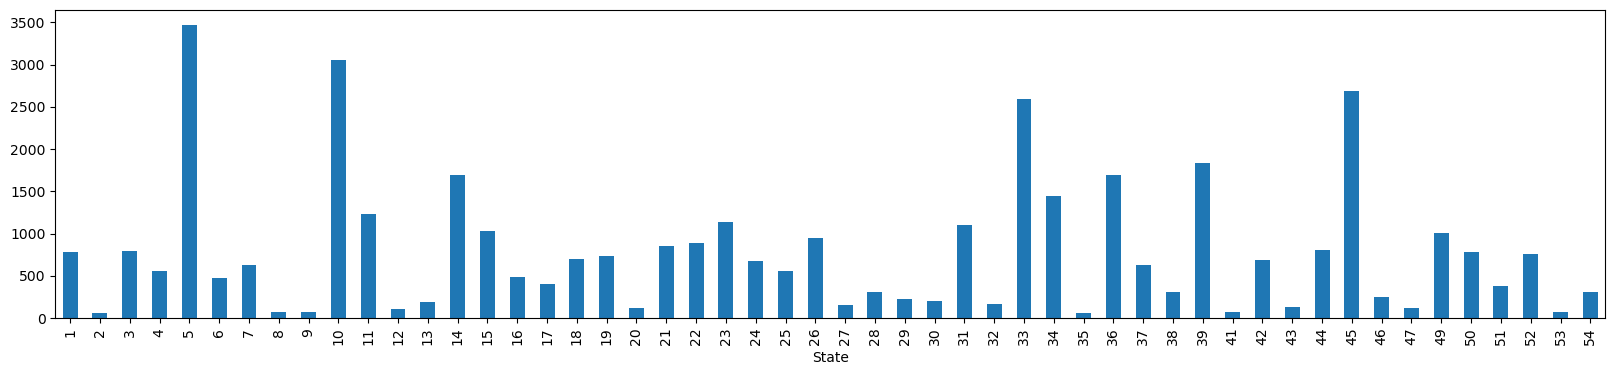

Some states have much more claims than other states, such the state 5, 10, 33, and 45.


In [36]:
# The pattern of State
plt.figure(figsize=(20, 4))
df_inp.groupby("State").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("Some states have much more claims than other states, such the state 5, 10, 33, and 45.")

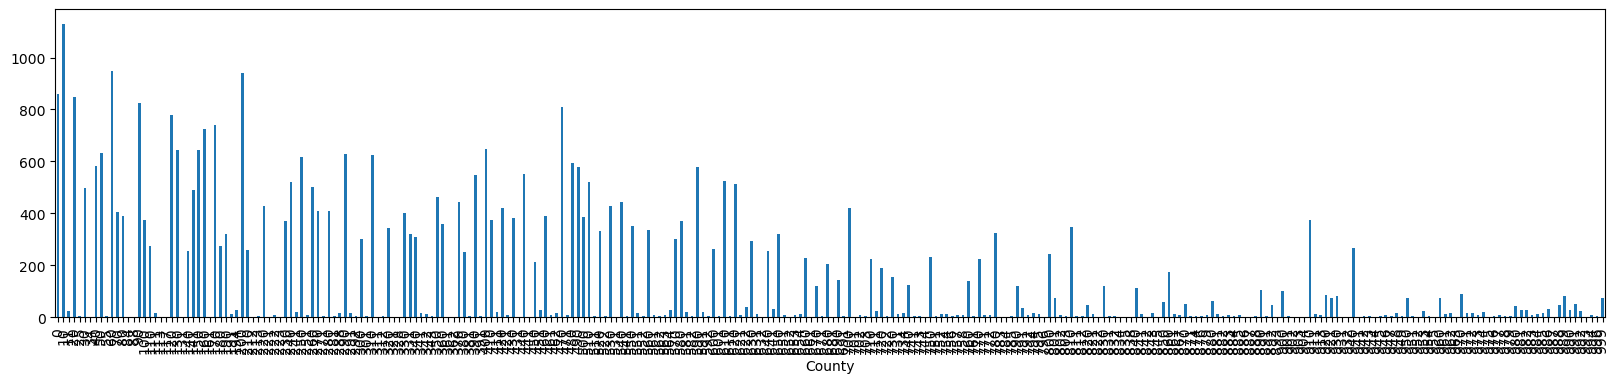

The number of claims across different County varies.


In [37]:
# The pattern of County
plt.figure(figsize=(20, 4))
df_inp.groupby("County").count()["ClaimID"].plot(kind="bar")
plt.show()

# Observation:
print("The number of claims across different County varies.")

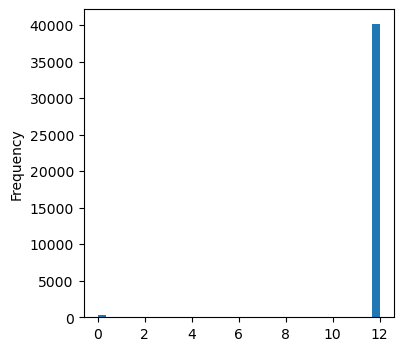

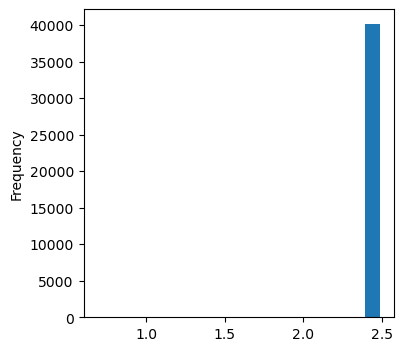

The median of the Age 12.00
The mean of the Age 11.92
Nearly all claim beneficiaries are covered for 12 months under Medicare Part A, rendering it useless for model training.


In [38]:
# The distribution of NoOfMonths_PartACov
plt.figure(figsize=(4, 4))
df_inp["NoOfMonths_PartACov"].plot(kind="hist",bins = int(1 + 3.322 * np.log(len(df_inp["NoOfMonths_PartACov"]))))
plt.show()

plt.figure(figsize=(4, 4))
df_inp[df_inp["NoOfMonths_PartACov"]>0]["NoOfMonths_PartACov"].apply(np.log).plot(kind="hist",bins = 20)
plt.show()

# The median and mean of the number of months that an individual has coverage under Medicare Part A
MedianNoOfMonths_PartACov = df_inp["NoOfMonths_PartACov"].median()
MeanNoOfMonths_PartACov = df_inp["NoOfMonths_PartACov"].mean()

# Observation: 
print(f"The median of the Age {MedianNoOfMonths_PartACov:.2f}")
print(f"The mean of the Age {MeanNoOfMonths_PartACov:.2f}")
print("Nearly all claim beneficiaries are covered for 12 months under Medicare Part A, rendering it useless for model training.")

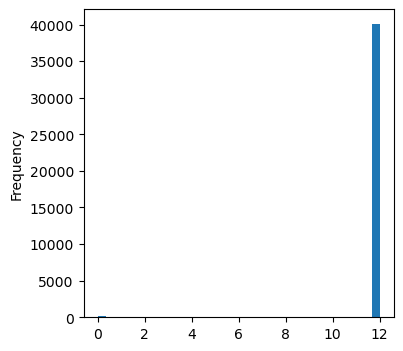

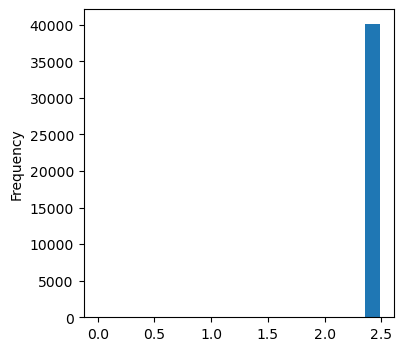

The median of the Age 12.00
The mean of the Age 11.92
Nearly all claim beneficiaries are covered for 12 months under Medicare Part B, rendering it useless for model training.


In [39]:
# The distribution of NoOfMonths_PartBCov
plt.figure(figsize=(4, 4))
df_inp["NoOfMonths_PartBCov"].plot(kind="hist",bins = int(1 + 3.322 * np.log(len(df_inp["NoOfMonths_PartBCov"]))))
plt.show()

plt.figure(figsize=(4, 4))
df_inp[df_inp["NoOfMonths_PartBCov"]>0]["NoOfMonths_PartBCov"].apply(np.log).plot(kind="hist",bins = 20)
plt.show()

# The median and mean of the number of months that an individual has coverage under Medicare Part A
MedianNoOfMonths_PartBCov = df_inp["NoOfMonths_PartBCov"].median()
MeanNoOfMonths_PartBCov = df_inp["NoOfMonths_PartBCov"].mean()

# Observation: 
print(f"The median of the Age {MedianNoOfMonths_PartBCov:.2f}")
print(f"The mean of the Age {MeanNoOfMonths_PartBCov:.2f}")
print("Nearly all claim beneficiaries are covered for 12 months under Medicare Part B, rendering it useless for model training.")

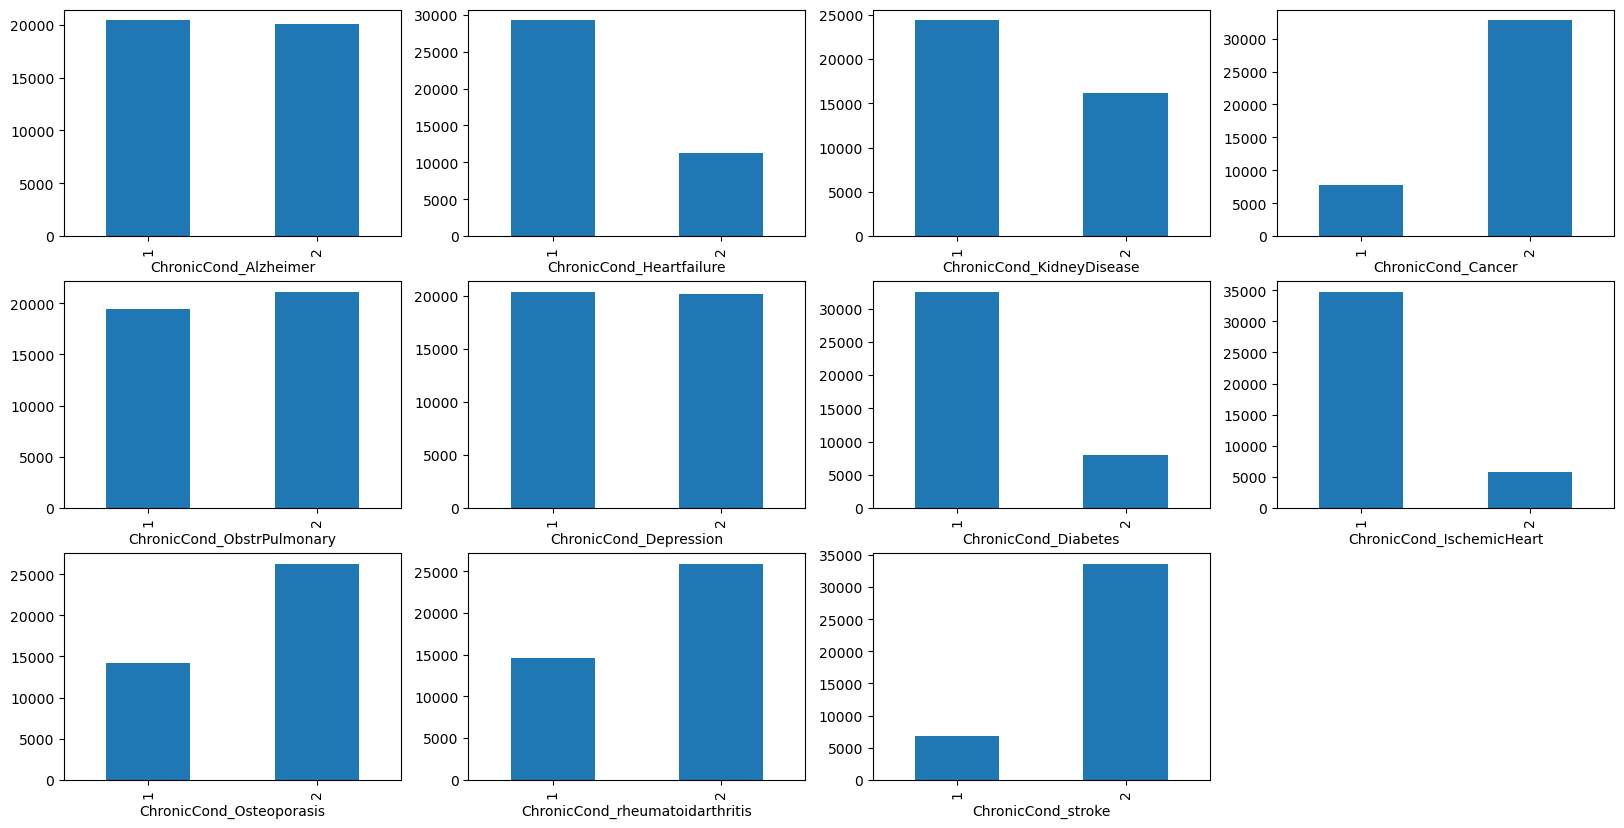

Each feature has only two categories, suggesting they probably represent the presence or absence of a specific disease.


In [40]:
# The pattern of the chronic conditions of various diseases
plt.figure(figsize=(20, 10))
plt.subplot(3, 4, 1)
df_inp.groupby("ChronicCond_Alzheimer").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 2)
df_inp.groupby("ChronicCond_Heartfailure").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 3)
df_inp.groupby("ChronicCond_KidneyDisease").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 4)
df_inp.groupby("ChronicCond_Cancer").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 5)
df_inp.groupby("ChronicCond_ObstrPulmonary").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 6)
df_inp.groupby("ChronicCond_Depression").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 7)
df_inp.groupby("ChronicCond_Diabetes").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 8)
df_inp.groupby("ChronicCond_IschemicHeart").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 9)
df_inp.groupby("ChronicCond_Osteoporasis").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 10)
df_inp.groupby("ChronicCond_rheumatoidarthritis").count()["ClaimID"].plot(kind="bar")

plt.subplot(3, 4, 11)
df_inp.groupby("ChronicCond_stroke").count()["ClaimID"].plot(kind="bar")
plt.show()

#Observation:
print("Each feature has only two categories, suggesting they probably represent the presence or absence of a specific disease.")

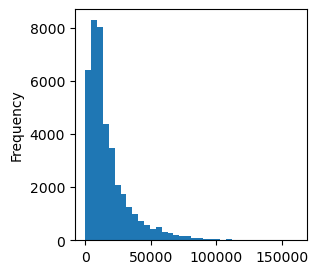

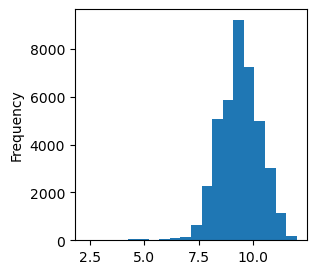

The median of the annual amount reimbursed for the treatment: 12000.00
The mean of the annual amount reimbursed for the treatment: 17533.75
The annual amount reimbursed for the treatment is positive skewed and approximately follows the log-normal distribution.


In [41]:
# The distribution of IPAnnualReimbursementAmt
plt.figure(figsize=(3, 3))
df_inp["IPAnnualReimbursementAmt"].plot(kind="hist",bins= int(1 + 3.322 * np.log(nrow)))
plt.show()

plt.figure(figsize=(3, 3))
df_inp[df_inp["IPAnnualReimbursementAmt"]>0]["IPAnnualReimbursementAmt"].apply(np.log).plot(kind="hist",bins= 20)
plt.show()

# The median and mean of the annual amount reimbursed for the treatment
MedianIPAnnualReimbursementAmt = df_inp["IPAnnualReimbursementAmt"].median()
MeanIPAnnualReimbursementAmt = df_inp["IPAnnualReimbursementAmt"].mean()

# Observation: 
print(f"The median of the annual amount reimbursed for the treatment: {MedianIPAnnualReimbursementAmt:.2f}")
print(f"The mean of the annual amount reimbursed for the treatment: {MeanIPAnnualReimbursementAmt:.2f}")
print("The annual amount reimbursed for the treatment is positive skewed and approximately follows the log-normal distribution.")

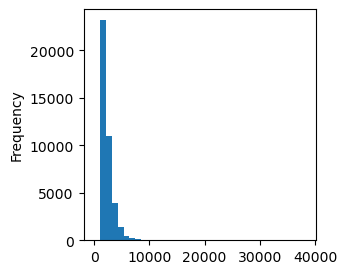

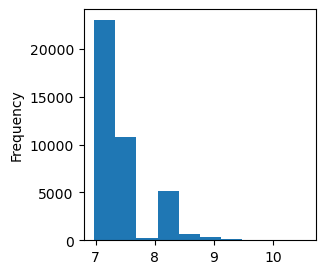

The median of the annual premium amount paid to the Insurance Agency towards the treatment: 1068.00
The mean of the annual premium amount paid to the Insurance Agency towards the treatment: 1887.81
The annual premium amount paid to the Insurance Agency towards the treatment is positive skewed. This skewness indicates a high frequency of zero values in the claims' Inpatient Annual Deductible Amount.


In [42]:
# The distribution of IPAnnualDeductibleAmt
plt.figure(figsize=(3, 3))
df_inp["IPAnnualDeductibleAmt"].plot(kind="hist",bins= int(1 + 3.322 * np.log(nrow)))
plt.show()

plt.figure(figsize=(3, 3))
df_inp[df_inp["IPAnnualDeductibleAmt"]>0]["IPAnnualDeductibleAmt"].apply(np.log).plot(kind="hist",bins= 10)
plt.show()

# The median and mean of the annual premium amount paid to the Insurance Agency towards the treatment
MedianIPAnnualDeductibleAmt = df_inp["IPAnnualDeductibleAmt"].median()
MeanIPAnnualDeductibleAmt = df_inp["IPAnnualDeductibleAmt"].mean()

# Observation: 
print(f"The median of the annual premium amount paid to the Insurance Agency towards the treatment: {MedianIPAnnualDeductibleAmt:.2f}")
print(f"The mean of the annual premium amount paid to the Insurance Agency towards the treatment: {MeanIPAnnualDeductibleAmt:.2f}")
print("The annual premium amount paid to the Insurance Agency towards the treatment is positive skewed. This skewness indicates a high frequency of zero values in the claims' Inpatient Annual Deductible Amount.")

##### (2). Analysis of interrelationships between categorical features and the target.

In [43]:
# The interrelationships between features and the target.
categorical_features = []
target = "PotentialFraud"

In [44]:
# BeneID and PotentialFraud
print("The categories of BeneID:",len(df_inp["BeneID"].unique()))

# Observation:
print("BeneID has high cardinality which is hard to aggregate, rendering it useless for model training")

The categories of BeneID: 31289
BeneID has high cardinality which is hard to aggregate, rendering it useless for model training


The categories of Provider: 2092


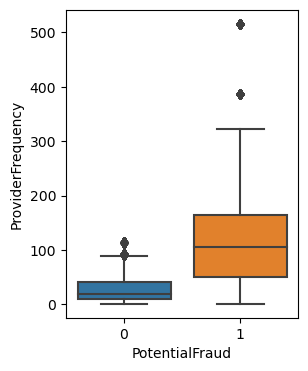

Provider has high cardinality, so we use ProviderFrequency for model training as it demonstrates a notable distinction between fraudulent and non-fraudulent claims.


In [45]:
# Provider and PotentialFraud
print("The categories of Provider:",len(df_inp["Provider"].unique()))

# ProviderFrequency and PotentialFraud
plt.figure(figsize=(3, 4))
sns.boxplot(x = "PotentialFraud",y = "ProviderFrequency",data =df_inp)
plt.show()

# Observation:
print("Provider has high cardinality, so we use ProviderFrequency for model training as it demonstrates a notable distinction between fraudulent and non-fraudulent claims.")

# incorporate the feature
# add to numerical_features

In [46]:
# Various Start Dates and PotentialFraud
ClaimStartDtMonth_fraud_count = df_inp.groupby(["ClaimStartDtMonth","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimStartDtMonth_count = df_inp.groupby(["ClaimStartDtMonth"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimStartDtMonth = pd.merge(ClaimStartDtMonth_fraud_count,ClaimStartDtMonth_count,on=["ClaimStartDtMonth"],how="left")
ClaimStartDtMonth["frequency"] = ClaimStartDtMonth["count"]/ClaimStartDtMonth["aggregation"]
ClaimStartDtMonth_pivot = ClaimStartDtMonth.pivot(index='ClaimStartDtMonth', columns='PotentialFraud', values='frequency')

ClaimStartDtWeekDay_fraud_count = df_inp.groupby(["ClaimStartDtWeekDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimStartDtWeekDay_count = df_inp.groupby(["ClaimStartDtWeekDay"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimStartDtWeekDay = pd.merge(ClaimStartDtWeekDay_fraud_count,ClaimStartDtWeekDay_count,on=["ClaimStartDtWeekDay"],how="left")
ClaimStartDtWeekDay["frequency"] = ClaimStartDtWeekDay["count"]/ClaimStartDtWeekDay["aggregation"]
ClaimStartDtWeekDay_pivot = ClaimStartDtWeekDay.pivot(index='ClaimStartDtWeekDay', columns='PotentialFraud', values='frequency')

ClaimStartDtDay_fraud_count = df_inp.groupby(["ClaimStartDtDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimStartDtDay_count = df_inp.groupby(["ClaimStartDtDay"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimStartDtDay = pd.merge(ClaimStartDtDay_fraud_count,ClaimStartDtDay_count,on=["ClaimStartDtDay"],how="left")
ClaimStartDtDay["frequency"] = ClaimStartDtDay["count"]/ClaimStartDtDay["aggregation"]
ClaimStartDtDay_pivot = ClaimStartDtDay.pivot(index='ClaimStartDtDay', columns='PotentialFraud', values='frequency')

AdmissionDtMonth_fraud_count = df_inp.groupby(["AdmissionDtMonth","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtMonth_count = df_inp.groupby(["AdmissionDtMonth"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtMonth = pd.merge(AdmissionDtMonth_fraud_count,AdmissionDtMonth_count,on=["AdmissionDtMonth"],how="left")
AdmissionDtMonth["frequency"] = AdmissionDtMonth["count"]/AdmissionDtMonth["aggregation"]
AdmissionDtMonth_pivot = AdmissionDtMonth.pivot(index='AdmissionDtMonth', columns='PotentialFraud', values='frequency')

AdmissionDtWeekDay_fraud_count = df_inp.groupby(["AdmissionDtWeekDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtWeekDay_count = df_inp.groupby(["AdmissionDtWeekDay"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtWeekDay = pd.merge(AdmissionDtWeekDay_fraud_count,AdmissionDtWeekDay_count,on=["AdmissionDtWeekDay"],how="left")
AdmissionDtWeekDay["frequency"] = AdmissionDtWeekDay["count"]/AdmissionDtWeekDay["aggregation"]
AdmissionDtWeekDay_pivot = AdmissionDtWeekDay.pivot(index='AdmissionDtWeekDay', columns='PotentialFraud', values='frequency')

AdmissionDtDay_fraud_count = df_inp.groupby(["AdmissionDtDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtDay_count = df_inp.groupby(["AdmissionDtDay"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtDay = pd.merge(AdmissionDtDay_fraud_count,AdmissionDtDay_count,on=["AdmissionDtDay"],how="left")
AdmissionDtDay["frequency"] = AdmissionDtDay["count"]/AdmissionDtDay["aggregation"]
AdmissionDtDay_pivot = AdmissionDtDay.pivot(index='AdmissionDtDay', columns='PotentialFraud', values='frequency')

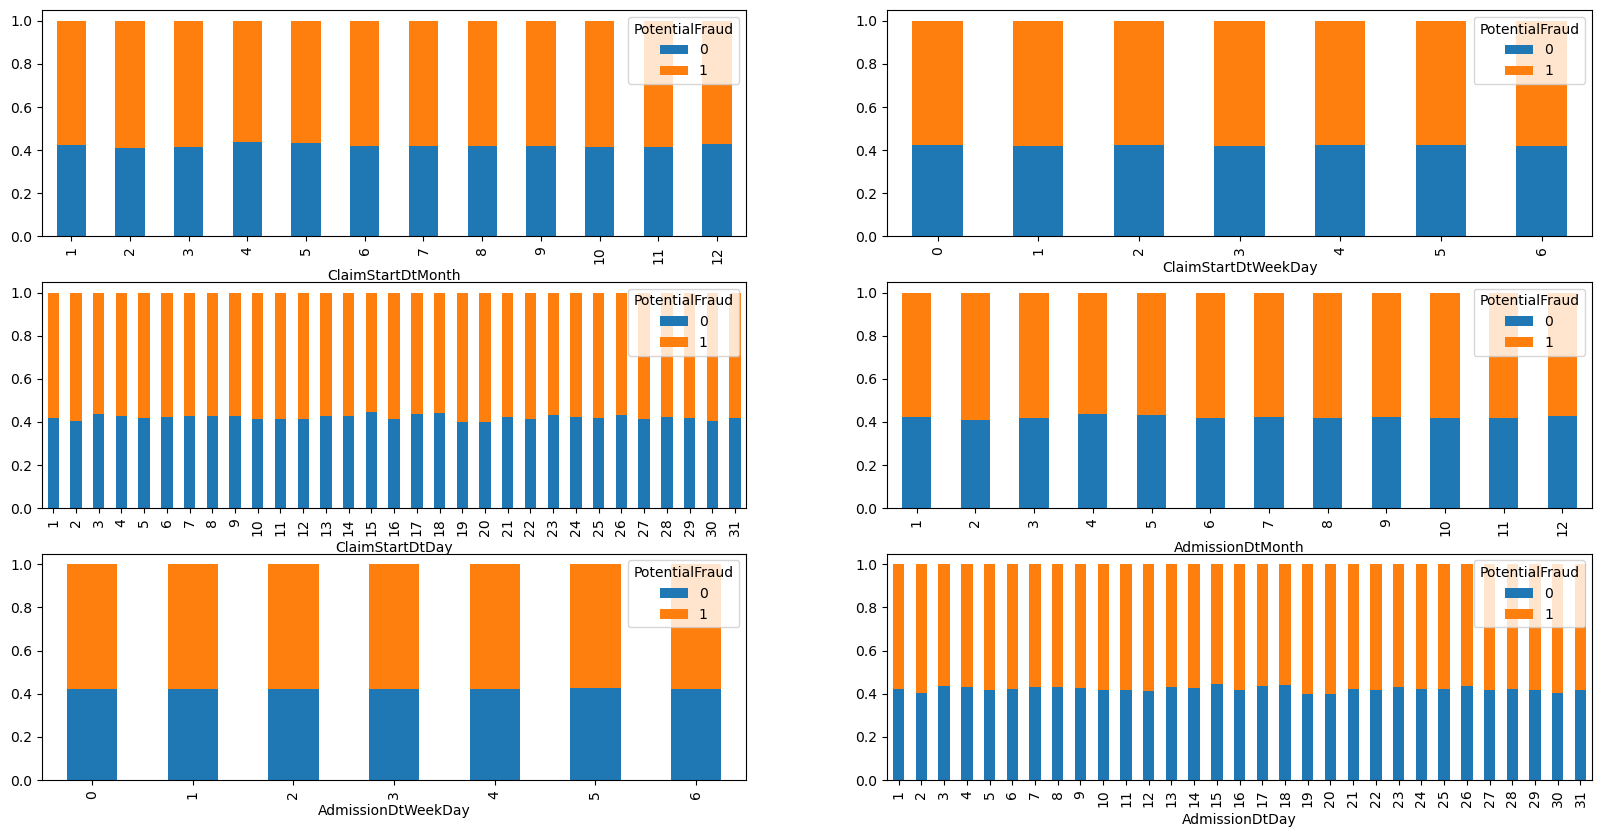

The fraud rate does not exhibit significant difference between different types of start dates,rendering these features useless for model training.


In [47]:
plt.figure(figsize=(20, 10))
plt.subplot(3, 2, 1)
ClaimStartDtMonth_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 2)
ClaimStartDtWeekDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 3)
ClaimStartDtDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 4)
AdmissionDtMonth_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 5)
AdmissionDtWeekDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 6)
AdmissionDtDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between different types of start dates,rendering these features useless for model training.")

In [48]:
# Various End Dates and PotentialFraud
ClaimEndDtMonth_fraud_count = df_inp.groupby(["ClaimEndDtMonth","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimEndDtMonth_count = df_inp.groupby(["ClaimEndDtMonth"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimEndDtMonth = pd.merge(ClaimEndDtMonth_fraud_count,ClaimEndDtMonth_count,on=["ClaimEndDtMonth"],how="left")
ClaimEndDtMonth["frequency"] = ClaimEndDtMonth["count"]/ClaimEndDtMonth["aggregation"]
ClaimEndDtMonth_pivot = ClaimEndDtMonth.pivot(index='ClaimEndDtMonth', columns='PotentialFraud', values='frequency')

ClaimEndDtWeekDay_fraud_count = df_inp.groupby(["ClaimEndDtWeekDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimEndDtWeekDay_count = df_inp.groupby(["ClaimEndDtWeekDay"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimEndDtWeekDay = pd.merge(ClaimEndDtWeekDay_fraud_count,ClaimEndDtWeekDay_count,on=["ClaimEndDtWeekDay"],how="left")
ClaimEndDtWeekDay["frequency"] = ClaimEndDtWeekDay["count"]/ClaimEndDtWeekDay["aggregation"]
ClaimEndDtWeekDay_pivot = ClaimEndDtWeekDay.pivot(index='ClaimEndDtWeekDay', columns='PotentialFraud', values='frequency')

ClaimEndDtDay_fraud_count = df_inp.groupby(["ClaimEndDtDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ClaimEndDtDay_count = df_inp.groupby(["ClaimEndDtDay"]).count()["ClaimID"].reset_index(name="aggregation")
ClaimEndDtDay = pd.merge(ClaimEndDtDay_fraud_count,ClaimEndDtDay_count,on=["ClaimEndDtDay"],how="left")
ClaimEndDtDay["frequency"] = ClaimEndDtDay["count"]/ClaimEndDtDay["aggregation"]
ClaimEndDtDay_pivot = ClaimEndDtDay.pivot(index='ClaimEndDtDay', columns='PotentialFraud', values='frequency')

AdmissionDtMonth_fraud_count = df_inp.groupby(["AdmissionDtMonth","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtMonth_count = df_inp.groupby(["AdmissionDtMonth"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtMonth = pd.merge(AdmissionDtMonth_fraud_count,AdmissionDtMonth_count,on=["AdmissionDtMonth"],how="left")
AdmissionDtMonth["frequency"] = AdmissionDtMonth["count"]/AdmissionDtMonth["aggregation"]
AdmissionDtMonth_pivot = AdmissionDtMonth.pivot(index='AdmissionDtMonth', columns='PotentialFraud', values='frequency')

AdmissionDtWeekDay_fraud_count = df_inp.groupby(["AdmissionDtWeekDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtWeekDay_count = df_inp.groupby(["AdmissionDtWeekDay"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtWeekDay = pd.merge(AdmissionDtWeekDay_fraud_count,AdmissionDtWeekDay_count,on=["AdmissionDtWeekDay"],how="left")
AdmissionDtWeekDay["frequency"] = AdmissionDtWeekDay["count"]/AdmissionDtWeekDay["aggregation"]
AdmissionDtWeekDay_pivot = AdmissionDtWeekDay.pivot(index='AdmissionDtWeekDay', columns='PotentialFraud', values='frequency')

AdmissionDtDay_fraud_count = df_inp.groupby(["AdmissionDtDay","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
AdmissionDtDay_count = df_inp.groupby(["AdmissionDtDay"]).count()["ClaimID"].reset_index(name="aggregation")
AdmissionDtDay = pd.merge(AdmissionDtDay_fraud_count,AdmissionDtDay_count,on=["AdmissionDtDay"],how="left")
AdmissionDtDay["frequency"] = AdmissionDtDay["count"]/AdmissionDtDay["aggregation"]
AdmissionDtDay_pivot = AdmissionDtDay.pivot(index='AdmissionDtDay', columns='PotentialFraud', values='frequency')

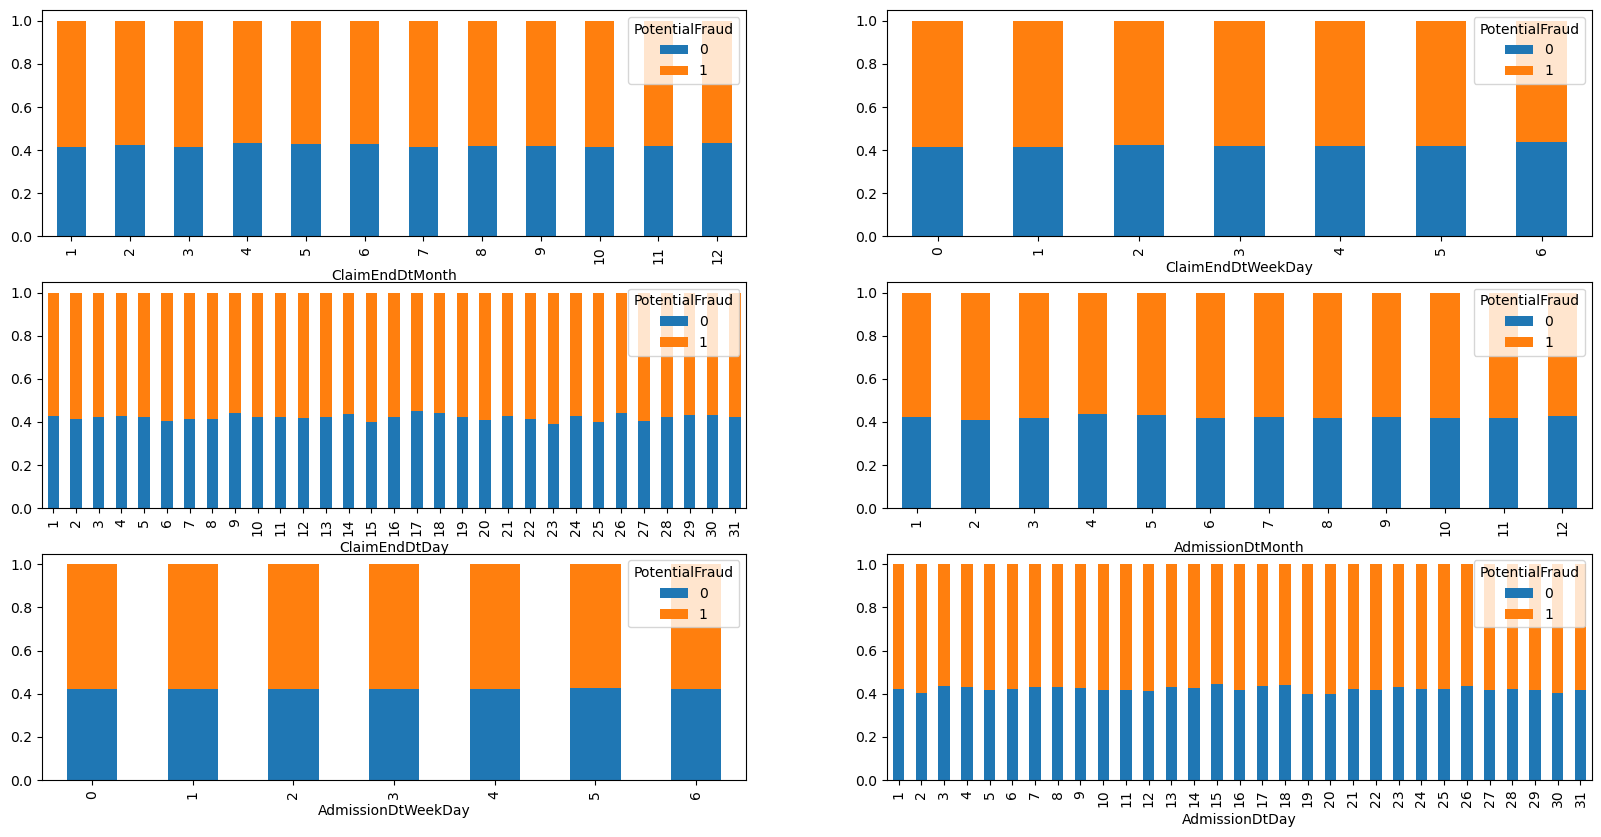

The fraud rate does not exhibit significant difference between different types of end dates,rendering these features useless for model training.


In [49]:
plt.figure(figsize=(20, 10))
plt.subplot(3, 2, 1)
ClaimEndDtMonth_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 2)
ClaimEndDtWeekDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 3)
ClaimEndDtDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 4)
AdmissionDtMonth_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 5)
AdmissionDtWeekDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 2, 6)
AdmissionDtDay_pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between different types of end dates,rendering these features useless for model training.")

<Figure size 600x600 with 0 Axes>

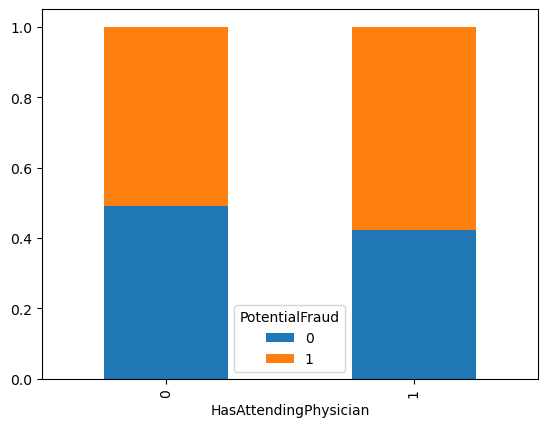

Claims with Attending Physicians seems more likely to be fraud. The information provided by this feature helps in model training.


In [50]:
# HasAttendingPhysician and PotentialFraud
HasAttendingPhysician_fraud_count = df_inp.groupby(["HasAttendingPhysician","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
HasAttendingPhysician_count = df_inp.groupby(["HasAttendingPhysician"]).count()["ClaimID"].reset_index(name="aggregation")
HasAttendingPhysician = pd.merge(HasAttendingPhysician_fraud_count,HasAttendingPhysician_count,on=["HasAttendingPhysician"],how="left")
HasAttendingPhysician["frequency"] = HasAttendingPhysician["count"]/HasAttendingPhysician["aggregation"]
HasAttendingPhysician_pivot = HasAttendingPhysician.pivot(index='HasAttendingPhysician', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
HasAttendingPhysician_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("Claims with Attending Physicians seems more likely to be fraud. The information provided by this feature helps in model training.")

# incorporate the feature
categorical_features.append("HasAttendingPhysician")

<Figure size 600x600 with 0 Axes>

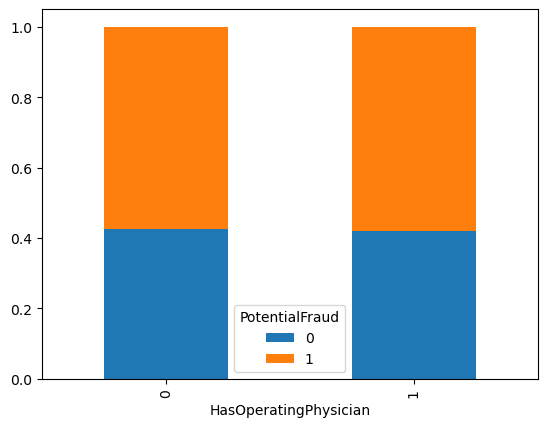

The fraud rate does not exhibit significant difference between claims with and without Operating Physicians, rendering this feature useless for model training.


In [51]:
# HasOperatingPhysician and PotentialFraud
HasOperatingPhysician_fraud_count = df_inp.groupby(["HasOperatingPhysician","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
HasOperatingPhysician_count = df_inp.groupby(["HasOperatingPhysician"]).count()["ClaimID"].reset_index(name="aggregation")
HasOperatingPhysician = pd.merge(HasOperatingPhysician_fraud_count,HasOperatingPhysician_count,on=["HasOperatingPhysician"],how="left")
HasOperatingPhysician["frequency"] = HasOperatingPhysician["count"]/HasOperatingPhysician["aggregation"]
HasOperatingPhysician_pivot = HasOperatingPhysician.pivot(index='HasOperatingPhysician', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
HasOperatingPhysician_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between claims with and without Operating Physicians, rendering this feature useless for model training.")


<Figure size 600x600 with 0 Axes>

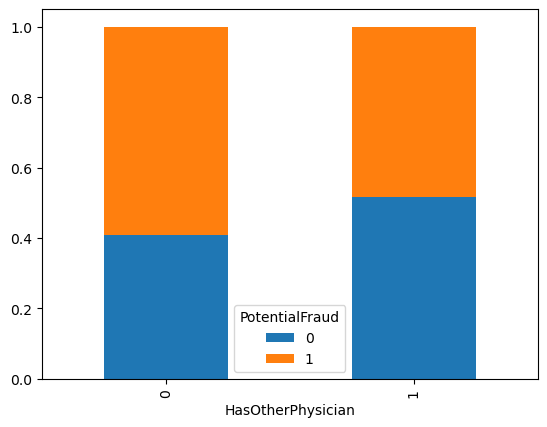

Claims without Other Physicians seems more likely to be fraud. The information provided by this feature helps in model training.


In [52]:
# HasOtherPhysician and PotentialFraud
HasOtherPhysician_fraud_count = df_inp.groupby(["HasOtherPhysician","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
HasOtherPhysician_count = df_inp.groupby(["HasOtherPhysician"]).count()["ClaimID"].reset_index(name="aggregation")
HasOtherPhysician = pd.merge(HasOtherPhysician_fraud_count,HasOtherPhysician_count,on=["HasOtherPhysician"],how="left")
HasOtherPhysician["frequency"] = HasOtherPhysician["count"]/HasOtherPhysician["aggregation"]
HasOtherPhysician_pivot = HasOtherPhysician.pivot(index='HasOtherPhysician', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
HasOtherPhysician_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("Claims without Other Physicians seems more likely to be fraud. The information provided by this feature helps in model training.")

# incorporate the feature
categorical_features.append("HasOtherPhysician")

The categories of ClmAdmitDiagnosisCode: 1928


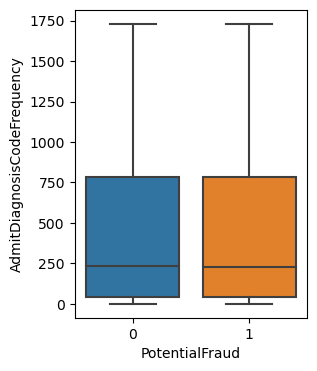

<Figure size 600x2000 with 0 Axes>

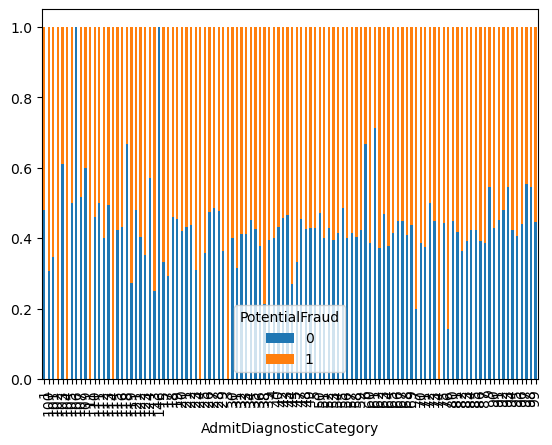

ClmAdmitDiagnosisCode has high cardinality, so we use AdmitDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.


In [53]:
# ClmAdmitDiagnosisCode and PotentialFraud
print("The categories of ClmAdmitDiagnosisCode:",len(df_inp["ClmAdmitDiagnosisCode"].unique()))

# AdmitDiagnosisCodeFrequency and PotentialFraud
plt.figure(figsize=(3, 4))
sns.boxplot(x = "PotentialFraud",y = "AdmitDiagnosisCodeFrequency",data =df_inp)
plt.show()

# AdmitDiagnosticCategory and PotentialFraud
ADC_fraud_count = df_inp.groupby(["AdmitDiagnosticCategory","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ADC_count = df_inp.groupby(["AdmitDiagnosticCategory"]).count()["ClaimID"].reset_index(name="aggregation")
ADC = pd.merge(ADC_fraud_count,ADC_count,on=["AdmitDiagnosticCategory"],how="left")
ADC["frequency"] = ADC["count"]/ADC["aggregation"]
ADC_pivot = ADC.pivot(index='AdmitDiagnosticCategory', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 20))
ADC_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("ClmAdmitDiagnosisCode has high cardinality, so we use AdmitDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.")

# incorporate the feature
categorical_features.append("AdmitDiagnosticCategory")

The categories of DiagnosisGroupCode: 736


<Figure size 1000x600 with 0 Axes>

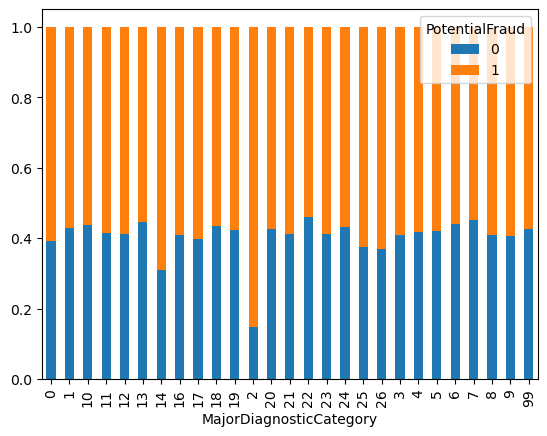

DiagnosisGroupCode has high cardinality, so we use MajorDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.


In [54]:
# DiagnosisGroupCode and PotentialFraud
print("The categories of DiagnosisGroupCode:",len(df_inp["DiagnosisGroupCode"].unique()))

# MajorDiagnosticCategory and PotentialFraud
MDC_fraud_count = df_inp.groupby(["MajorDiagnosticCategory","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
MDC_count = df_inp.groupby(["MajorDiagnosticCategory"]).count()["ClaimID"].reset_index(name="aggregation")
MDC = pd.merge(MDC_fraud_count,MDC_count,on=["MajorDiagnosticCategory"],how="left")
MDC["frequency"] = MDC["count"]/MDC["aggregation"]
MDC_pivot = MDC.pivot(index='MajorDiagnosticCategory', columns='PotentialFraud', values='frequency')
plt.figure(figsize=(10, 6))
MDC_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("DiagnosisGroupCode has high cardinality, so we use MajorDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.")

# incorporate the feature
categorical_features.append("MajorDiagnosticCategory")

The categories of ClmDiagnosisCode_1: 2254


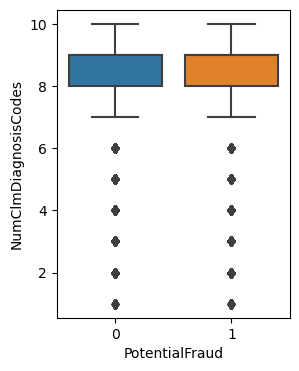

<Figure size 300x600 with 0 Axes>

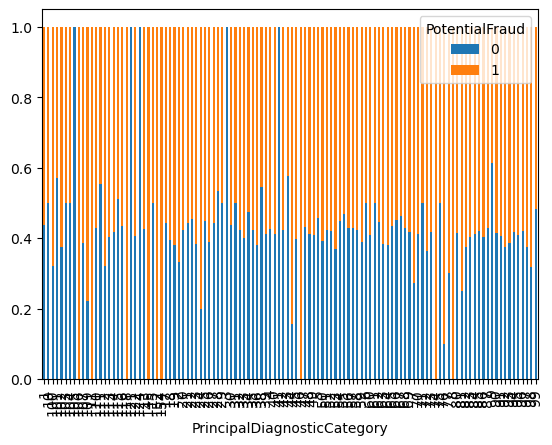

The categories of ClmDiagnosisCode_2 after transformation: 130
The categories of ClmDiagnosisCode_3 after transformation: 129
The categories of ClmDiagnosisCode_4 after transformation: 134
The categories of ClmDiagnosisCode_5 after transformation: 130
The categories of ClmDiagnosisCode_6 after transformation: 134
The categories of ClmDiagnosisCode_7 after transformation: 127
The categories of ClmDiagnosisCode_8 after transformation: 127
The categories of ClmDiagnosisCode_9 after transformation: 127
The categories of ClmDiagnosisCode_10 after transformation: 104
ClmDiagnosisCode_1 has high cardinality, so we use PrincipalDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.
ClmDiagnosisCode from 2 to 10 is not as important as the ClmDiagnosisCode_1.  Utilizing all of them even, after transformation to Diagnostic Category, could lead to overfitting. Hence, only PrincipalDiagnosticCategory will be included in the model to m

In [55]:
# ClmDiagnosisCode_1 and PotentialFraud
print("The categories of ClmDiagnosisCode_1:",len(df_inp["ClmDiagnosisCode_1"].unique()))

# NumClmDiagnosisCodes and PotentialFraud
plt.figure(figsize=(3, 4))
sns.boxplot(x = "PotentialFraud",y = "NumClmDiagnosisCodes",data =df_inp)
plt.show()

# PrincipalDiagnosticCategory and PotentialFraud
PDC_fraud_count = df_inp.groupby(["PrincipalDiagnosticCategory","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
PDC_count = df_inp.groupby(["PrincipalDiagnosticCategory"]).count()["ClaimID"].reset_index(name="aggregation")
PDC = pd.merge(PDC_fraud_count,PDC_count,on=["PrincipalDiagnosticCategory"],how="left")
PDC["frequency"] = PDC["count"]/PDC["aggregation"]
PDC_pivot = PDC.pivot(index='PrincipalDiagnosticCategory', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(3, 6))
PDC_pivot.plot(kind='bar', stacked=True)
plt.show()

# ClmDiagnosisCode_2~10 and PotentialFraud
print("The categories of ClmDiagnosisCode_2 after transformation:",len(df_inp["ClmDiagnosisCode_2"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_3 after transformation:",len(df_inp["ClmDiagnosisCode_3"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_4 after transformation:",len(df_inp["ClmDiagnosisCode_4"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_5 after transformation:",len(df_inp["ClmDiagnosisCode_5"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_6 after transformation:",len(df_inp["ClmDiagnosisCode_6"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_7 after transformation:",len(df_inp["ClmDiagnosisCode_7"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_8 after transformation:",len(df_inp["ClmDiagnosisCode_8"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_9 after transformation:",len(df_inp["ClmDiagnosisCode_9"].apply(CDC_to_TDC).unique()))
print("The categories of ClmDiagnosisCode_10 after transformation:",len(df_inp["ClmDiagnosisCode_10"].apply(CDC_to_TDC).unique()))

# Observation:
print("ClmDiagnosisCode_1 has high cardinality, so we use PrincipalDiagnosticCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.")
print("ClmDiagnosisCode from 2 to 10 is not as important as the ClmDiagnosisCode_1.  Utilizing all of them even, after transformation to Diagnostic Category, could lead to overfitting. Hence, only PrincipalDiagnosticCategory will be included in the model to maintain the predictive efficiency.")

# incorporate the feature
categorical_features.append("PrincipalDiagnosticCategory")

The categories of ClmProcedureCode_1: 1118


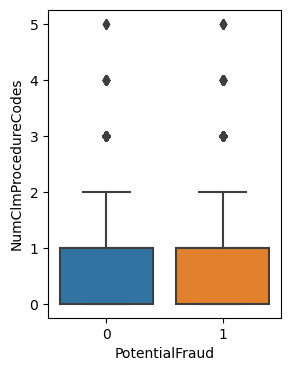

<Figure size 600x600 with 0 Axes>

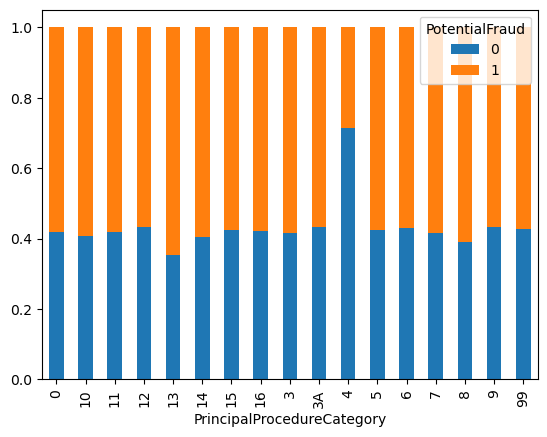

The categories of ClmProcedureCode_2 after transformation: 17
The categories of ClmProcedureCode_3 after transformation: 16
The categories of ClmProcedureCode_4 after transformation: 13
The categories of ClmProcedureCode_5 after transformation: 5
ClmProcedureCode_1 has high cardinality, so we use PrincipalProcedureCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.
ClmProcedureCode from 2 to 5 is not as important as the ClmProcedureCode_1.  Utilizing all of them even, after transformation to Procedure Category, could lead to overfitting. Hence, only PrincipalProcedureCategory will be included in the model to maintain the predictive efficiency.


In [56]:
# ClmProcedureCode_1  and PotentialFraud
print("The categories of ClmProcedureCode_1:",len(df_inp["ClmProcedureCode_1"].unique()))

# NumProcedureCodes and PotentialFraud
plt.figure(figsize=(3, 4))
sns.boxplot(x = "PotentialFraud",y = "NumClmProcedureCodes",data =df_inp)
plt.show()

# PrincipalProcedureCategory and PotentialFraud
PPC_fraud_count = df_inp.groupby(["PrincipalProcedureCategory","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
PPC_count = df_inp.groupby(["PrincipalProcedureCategory"]).count()["ClaimID"].reset_index(name="aggregation")
PPC = pd.merge(PPC_fraud_count,PPC_count,on=["PrincipalProcedureCategory"],how="left")
PPC["frequency"] = PPC["count"]/PPC["aggregation"]
PPC_pivot = PPC.pivot(index='PrincipalProcedureCategory', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
PPC_pivot.plot(kind='bar', stacked=True)
plt.show()

# ClmDiagnosisCode_2~10 and PotentialFraud
print("The categories of ClmProcedureCode_2 after transformation:",len(df_inp["ClmProcedureCode_2"].apply(CPC_to_PPC).unique()))
print("The categories of ClmProcedureCode_3 after transformation:",len(df_inp["ClmProcedureCode_3"].apply(CPC_to_PPC).unique()))
print("The categories of ClmProcedureCode_4 after transformation:",len(df_inp["ClmProcedureCode_4"].apply(CPC_to_PPC).unique()))
print("The categories of ClmProcedureCode_5 after transformation:",len(df_inp["ClmProcedureCode_5"].apply(CPC_to_PPC).unique()))

# Observation:
print("ClmProcedureCode_1 has high cardinality, so we use PrincipalProcedureCategory for model training as it demonstrates a notable distinction in fruad rate across various categories.")
print("ClmProcedureCode from 2 to 5 is not as important as the ClmProcedureCode_1.  Utilizing all of them even, after transformation to Procedure Category, could lead to overfitting. Hence, only PrincipalProcedureCategory will be included in the model to maintain the predictive efficiency.")

# incorporate the feature
categorical_features.append("PrincipalProcedureCategory")

<Figure size 600x600 with 0 Axes>

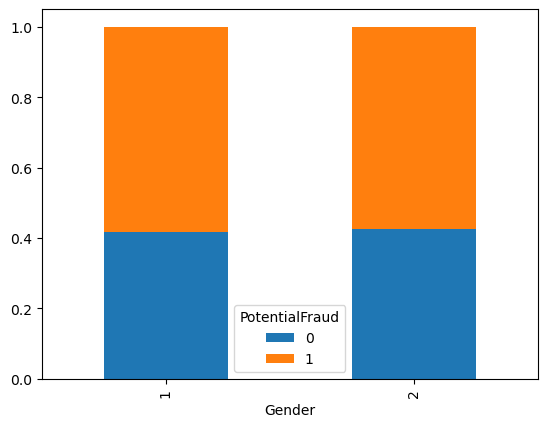

The fraud rate does not exhibit significant difference between claims involving beneficiaries of different genders, rendering this feature useless for model training.


In [57]:
# Gender and PotentialFraud
Gender_fraud_count = df_inp.groupby(["Gender","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
Gender_count = df_inp.groupby(["Gender"]).count()["ClaimID"].reset_index(name="aggregation")
Gender = pd.merge(Gender_fraud_count,Gender_count,on=["Gender"],how="left")
Gender["frequency"] = Gender["count"]/Gender["aggregation"]
Gender_pivot = Gender.pivot(index='Gender', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
Gender_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between claims involving beneficiaries of different genders, rendering this feature useless for model training.")

<Figure size 600x600 with 0 Axes>

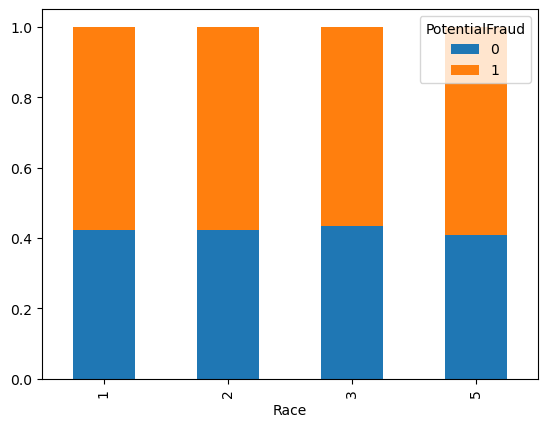

Claims involving beneficiaries with different races do not present a significant difference, and coupled with concerns about fairness, race will be excluded from the model training.


In [58]:
# Race and PotentialFraud
Race_fraud_count = df_inp.groupby(["Race","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
Race_count = df_inp.groupby(["Race"]).count()["ClaimID"].reset_index(name="aggregation")
Race = pd.merge(Race_fraud_count,Race_count,on=["Race"],how="left")
Race["frequency"] = Race["count"]/Race["aggregation"]
Race_pivot = Race.pivot(index='Race', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
Race_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("Claims involving beneficiaries with different races do not present a significant difference, and coupled with concerns about fairness, race will be excluded from the model training.")

<Figure size 600x600 with 0 Axes>

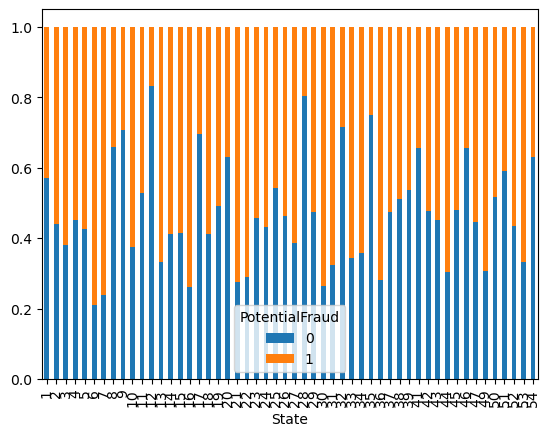

State will be included in model training as it demonstrates a notable distinction in fruad rate across various categories.


In [59]:
# State and PotentialFraud
State_fraud_count = df_inp.groupby(["State","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
State_count = df_inp.groupby(["State"]).count()["ClaimID"].reset_index(name="aggregation")
State = pd.merge(State_fraud_count,State_count,on=["State"],how="left")
State["frequency"] = State["count"]/State["aggregation"]
State_pivot = State.pivot(index='State', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
State_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("State will be included in model training as it demonstrates a notable distinction in fruad rate across various categories.")

# incorporate the feature
categorical_features.append("State")

In [60]:
# County and PotentialFraud
print("The categories of County:",len(df_inp["County"].unique()))

# Observation: 
print("County will be excluded from the model training due to its high cardinality, and since State already provides sufficient geographical representation in the model.")

The categories of County: 286
County will be excluded from the model training due to its high cardinality, and since State already provides sufficient geographical representation in the model.


<Figure size 600x600 with 0 Axes>

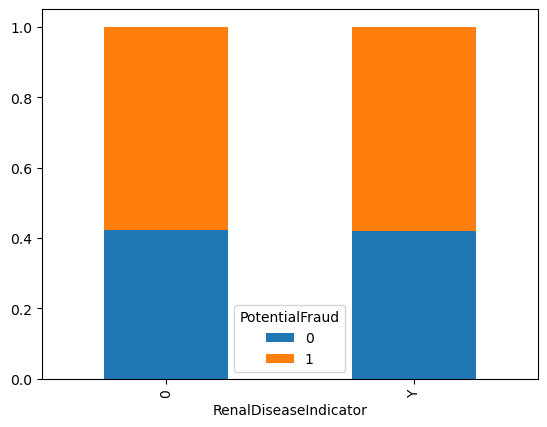

The fraud rate does not exhibit significant difference between claims involving beneficiaries with or without RenalDiseaseIndicator, rendering this feature useless for model training.


In [61]:
# RenalDiseaseIndicator and PotentialFraud
RenalDiseaseIndicator_fraud_count = df_inp.groupby(["RenalDiseaseIndicator","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
RenalDiseaseIndicator_count = df_inp.groupby(["RenalDiseaseIndicator"]).count()["ClaimID"].reset_index(name="aggregation")
RenalDiseaseIndicator = pd.merge(RenalDiseaseIndicator_fraud_count,RenalDiseaseIndicator_count,on=["RenalDiseaseIndicator"],how="left")
RenalDiseaseIndicator["frequency"] = RenalDiseaseIndicator["count"]/RenalDiseaseIndicator["aggregation"]
RenalDiseaseIndicator_pivot = RenalDiseaseIndicator.pivot(index='RenalDiseaseIndicator', columns='PotentialFraud', values='frequency')

plt.figure(figsize=(6, 6))
RenalDiseaseIndicator_pivot.plot(kind='bar', stacked=True)
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between claims involving beneficiaries with or without RenalDiseaseIndicator, rendering this feature useless for model training.")

In [62]:
# Chronic Condition of various diseases and PotentialFraud
ChronicCond_Alzheimer_fraud_count = df_inp.groupby(["ChronicCond_Alzheimer","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Alzheimer_count = df_inp.groupby(["ChronicCond_Alzheimer"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Alzheimer = pd.merge(ChronicCond_Alzheimer_fraud_count,ChronicCond_Alzheimer_count,on=["ChronicCond_Alzheimer"],how="left")
ChronicCond_Alzheimer["frequency"] = ChronicCond_Alzheimer["count"]/ChronicCond_Alzheimer["aggregation"]
ChronicCond_Alzheimer_pivot = ChronicCond_Alzheimer.pivot(index='ChronicCond_Alzheimer', columns='PotentialFraud', values='frequency')

ChronicCond_Heartfailure_fraud_count = df_inp.groupby(["ChronicCond_Heartfailure","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Heartfailure_count = df_inp.groupby(["ChronicCond_Heartfailure"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Heartfailure = pd.merge(ChronicCond_Heartfailure_fraud_count,ChronicCond_Heartfailure_count,on=["ChronicCond_Heartfailure"],how="left")
ChronicCond_Heartfailure["frequency"] = ChronicCond_Heartfailure["count"]/ChronicCond_Heartfailure["aggregation"]
ChronicCond_Heartfailure_pivot = ChronicCond_Heartfailure.pivot(index='ChronicCond_Heartfailure', columns='PotentialFraud', values='frequency')

ChronicCond_KidneyDisease_fraud_count = df_inp.groupby(["ChronicCond_KidneyDisease","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_KidneyDisease_count = df_inp.groupby(["ChronicCond_KidneyDisease"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_KidneyDisease = pd.merge(ChronicCond_KidneyDisease_fraud_count,ChronicCond_KidneyDisease_count,on=["ChronicCond_KidneyDisease"],how="left")
ChronicCond_KidneyDisease["frequency"] = ChronicCond_KidneyDisease["count"]/ChronicCond_KidneyDisease["aggregation"]
ChronicCond_KidneyDisease_pivot = ChronicCond_KidneyDisease.pivot(index='ChronicCond_KidneyDisease', columns='PotentialFraud', values='frequency')

ChronicCond_Cancer_fraud_count = df_inp.groupby(["ChronicCond_Cancer","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Cancer_count = df_inp.groupby(["ChronicCond_Cancer"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Cancer = pd.merge(ChronicCond_Cancer_fraud_count,ChronicCond_Cancer_count,on=["ChronicCond_Cancer"],how="left")
ChronicCond_Cancer["frequency"] = ChronicCond_Cancer["count"]/ChronicCond_Cancer["aggregation"]
ChronicCond_Cancer_pivot = ChronicCond_Cancer.pivot(index='ChronicCond_Cancer', columns='PotentialFraud', values='frequency')

ChronicCond_ObstrPulmonary_fraud_count = df_inp.groupby(["ChronicCond_ObstrPulmonary","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_ObstrPulmonary_count = df_inp.groupby(["ChronicCond_ObstrPulmonary"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_ObstrPulmonary = pd.merge(ChronicCond_ObstrPulmonary_fraud_count,ChronicCond_ObstrPulmonary_count,on=["ChronicCond_ObstrPulmonary"],how="left")
ChronicCond_ObstrPulmonary["frequency"] = ChronicCond_ObstrPulmonary["count"]/ChronicCond_ObstrPulmonary["aggregation"]
ChronicCond_ObstrPulmonary_pivot = ChronicCond_ObstrPulmonary.pivot(index='ChronicCond_ObstrPulmonary', columns='PotentialFraud', values='frequency')

ChronicCond_Depression_fraud_count = df_inp.groupby(["ChronicCond_Depression","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Depression_count = df_inp.groupby(["ChronicCond_Depression"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Depression = pd.merge(ChronicCond_Depression_fraud_count,ChronicCond_Depression_count,on=["ChronicCond_Depression"],how="left")
ChronicCond_Depression["frequency"] = ChronicCond_Depression["count"]/ChronicCond_Depression["aggregation"]
ChronicCond_Depression_pivot = ChronicCond_Depression.pivot(index='ChronicCond_Depression', columns='PotentialFraud', values='frequency')

ChronicCond_Diabetes_fraud_count = df_inp.groupby(["ChronicCond_Diabetes","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Diabetes_count = df_inp.groupby(["ChronicCond_Diabetes"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Diabetes = pd.merge(ChronicCond_Diabetes_fraud_count,ChronicCond_Diabetes_count,on=["ChronicCond_Diabetes"],how="left")
ChronicCond_Diabetes["frequency"] = ChronicCond_Diabetes["count"]/ChronicCond_Diabetes["aggregation"]
ChronicCond_Diabetes_pivot = ChronicCond_Diabetes.pivot(index='ChronicCond_Diabetes', columns='PotentialFraud', values='frequency')

ChronicCond_IschemicHeart_fraud_count = df_inp.groupby(["ChronicCond_IschemicHeart","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_IschemicHeart_count = df_inp.groupby(["ChronicCond_IschemicHeart"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_IschemicHeart = pd.merge(ChronicCond_IschemicHeart_fraud_count,ChronicCond_IschemicHeart_count,on=["ChronicCond_IschemicHeart"],how="left")
ChronicCond_IschemicHeart["frequency"] = ChronicCond_IschemicHeart["count"]/ChronicCond_IschemicHeart["aggregation"]
ChronicCond_IschemicHeart_pivot = ChronicCond_IschemicHeart.pivot(index='ChronicCond_IschemicHeart', columns='PotentialFraud', values='frequency')

ChronicCond_Osteoporasis_fraud_count = df_inp.groupby(["ChronicCond_Osteoporasis","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_Osteoporasis_count = df_inp.groupby(["ChronicCond_Osteoporasis"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_Osteoporasis = pd.merge(ChronicCond_Osteoporasis_fraud_count,ChronicCond_Osteoporasis_count,on=["ChronicCond_Osteoporasis"],how="left")
ChronicCond_Osteoporasis["frequency"] = ChronicCond_Osteoporasis["count"]/ChronicCond_Osteoporasis["aggregation"]
ChronicCond_Osteoporasis_pivot = ChronicCond_Osteoporasis.pivot(index='ChronicCond_Osteoporasis', columns='PotentialFraud', values='frequency')

ChronicCond_rheumatoidarthritis_fraud_count = df_inp.groupby(["ChronicCond_rheumatoidarthritis","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_rheumatoidarthritis_count = df_inp.groupby(["ChronicCond_rheumatoidarthritis"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_rheumatoidarthritis = pd.merge(ChronicCond_rheumatoidarthritis_fraud_count,ChronicCond_rheumatoidarthritis_count,on=["ChronicCond_rheumatoidarthritis"],how="left")
ChronicCond_rheumatoidarthritis["frequency"] = ChronicCond_rheumatoidarthritis["count"]/ChronicCond_rheumatoidarthritis["aggregation"]
ChronicCond_rheumatoidarthritis_pivot = ChronicCond_rheumatoidarthritis.pivot(index='ChronicCond_rheumatoidarthritis', columns='PotentialFraud', values='frequency')

ChronicCond_stroke_fraud_count = df_inp.groupby(["ChronicCond_stroke","PotentialFraud"]).count()["ClaimID"].reset_index(name="count")
ChronicCond_stroke_count = df_inp.groupby(["ChronicCond_stroke"]).count()["ClaimID"].reset_index(name="aggregation")
ChronicCond_stroke = pd.merge(ChronicCond_stroke_fraud_count,ChronicCond_stroke_count,on=["ChronicCond_stroke"],how="left")
ChronicCond_stroke["frequency"] = ChronicCond_stroke["count"]/ChronicCond_stroke["aggregation"]
ChronicCond_stroke_pivot = ChronicCond_stroke.pivot(index='ChronicCond_stroke', columns='PotentialFraud', values='frequency')



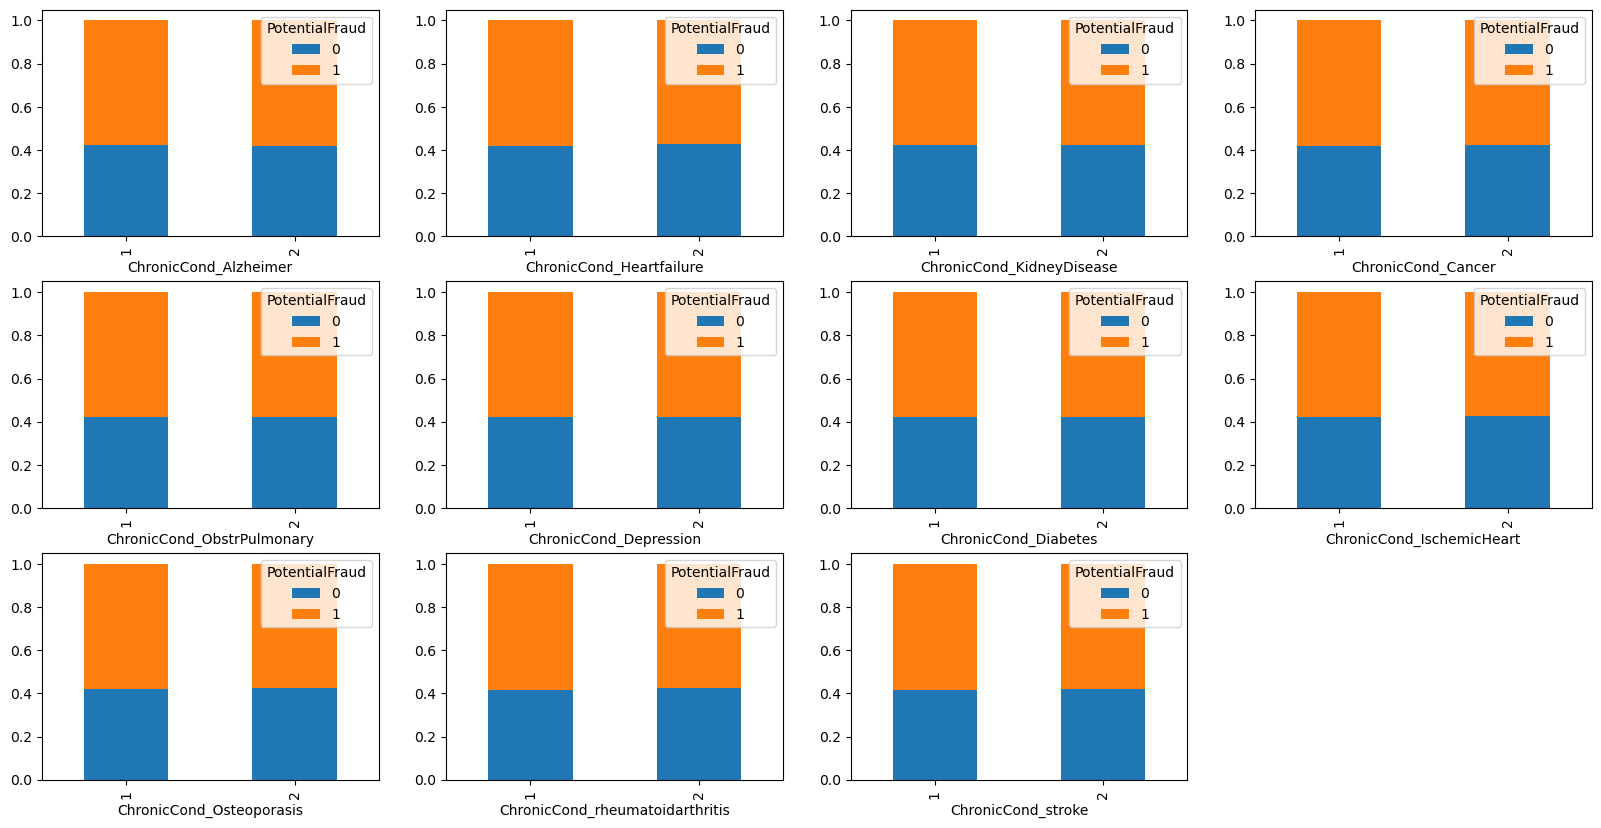

The fraud rate does not exhibit significant difference between claims involving beneficiaries with or without any Chronic Condition of diseases,rendering these features useless for model training.


In [63]:
plt.figure(figsize=(20, 10))

plt.subplot(3, 4, 1)
ChronicCond_Alzheimer_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 4, 2)
ChronicCond_Heartfailure_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 3)
ChronicCond_KidneyDisease_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 4)
ChronicCond_Cancer_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 5)
ChronicCond_ObstrPulmonary_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 6)
ChronicCond_Depression_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 7)
ChronicCond_Diabetes_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 8)
ChronicCond_IschemicHeart_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.subplot(3, 4, 9)
ChronicCond_Osteoporasis_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 10)
ChronicCond_rheumatoidarthritis_pivot.plot(kind='bar', stacked=True, ax=plt.gca())


plt.subplot(3, 4, 11)
ChronicCond_stroke_pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.show()

# Observation:
print("The fraud rate does not exhibit significant difference between claims involving beneficiaries with or without any Chronic Condition of diseases,rendering these features useless for model training.")

##### (3). Analysis of correlation between numerical features and with the target.

In [64]:
# The correlation between features and the target.
numerical_features = ["ClaimStartDt","ClaimEndDt","ClaimDuration","InscClaimAmtReimbursed","ProviderFrequency","AdmissionDt","DischargeDt","HospitalStayDuration","VisitInterval","DOB","DOD","Age","IPAnnualReimbursementAmt","IPAnnualDeductibleAmt"]
numerical_df = df_inp[numerical_features + [target]]
numerical_corr = numerical_df.corr()
numerical_corr

,ClaimStartDt,ClaimEndDt,ClaimDuration,InscClaimAmtReimbursed,ProviderFrequency,AdmissionDt,DischargeDt,HospitalStayDuration,VisitInterval,DOB,DOD,Age,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,PotentialFraud
ClaimStartDt,1.000000,0.998560,-0.067226,-0.012120,-0.005580,0.999996,0.998560,-0.067362,0.454266,0.009753,0.049069,0.012046,-0.050490,-0.050424,-0.002175
ClaimEndDt,0.998560,1.000000,-0.013599,0.005175,-0.005212,0.998554,1.000000,-0.013820,0.453674,0.010088,0.049144,0.011680,-0.037144,-0.046495,-0.001310
ClaimDuration,-0.067226,-0.013599,1.000000,0.322124,0.007062,-0.067243,-0.013610,0.998437,-0.027146,0.005842,-0.000594,-0.007307,0.250237,0.075104,0.016177
InscClaimAmtReimbursed,-0.012120,0.005175,0.322124,1.000000,0.003721,-0.012138,0.005170,0.321818,-0.009940,-0.001142,-0.001250,0.000877,0.610697,0.037112,0.025286
ProviderFrequency,-0.005580,-0.005212,0.007062,0.003721,1.000000,-0.005597,-0.005213,0.007354,0.006843,-0.006154,0.005616,0.006032,0.006809,0.003972,0.517386
AdmissionDt,0.999996,0.998554,-0.067243,-0.012138,-0.005597,1.000000,0.998555,-0.067542,0.454201,0.009766,0.049063,0.012033,-0.050516,-0.050451,-0.002176
DischargeDt,0.998560,1.000000,-0.013610,0.005170,-0.005213,0.998555,1.000000,-0.013826,0.453674,0.010084,0.049142,0.011684,-0.037147,-0.046496,-0.001317
HospitalStayDuration,-0.067362,-0.013820,0.998437,0.321818,0.007354,-0.067542,-0.013826,1.000000,-0.025748,0.005501,-0.000516,-0.006970,0.250260,0.075494,0.016024
VisitInterval,0.454266,0.453674,-0.027146,-0.009940,0.006843,0.454201,0.453674,-0.025748,1.000000,0.006663,0.033927,0.001888,-0.097022,-0.046047,-0.000967
DOB,0.009753,0.010088,0.005842,-0.001142,-0.006154,0.009766,0.010084,0.005501,0.006663,1.000000,0.007645,-0.999762,-0.010540,-0.012068,-0.003256


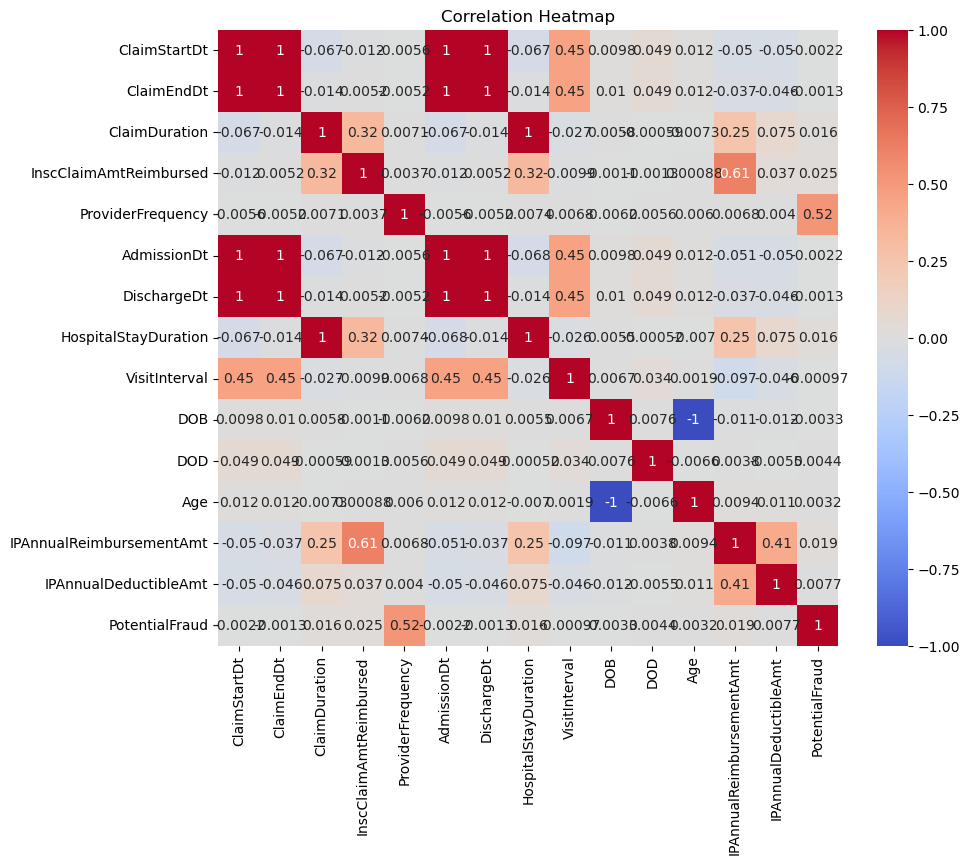

The figure layout has changed to tight


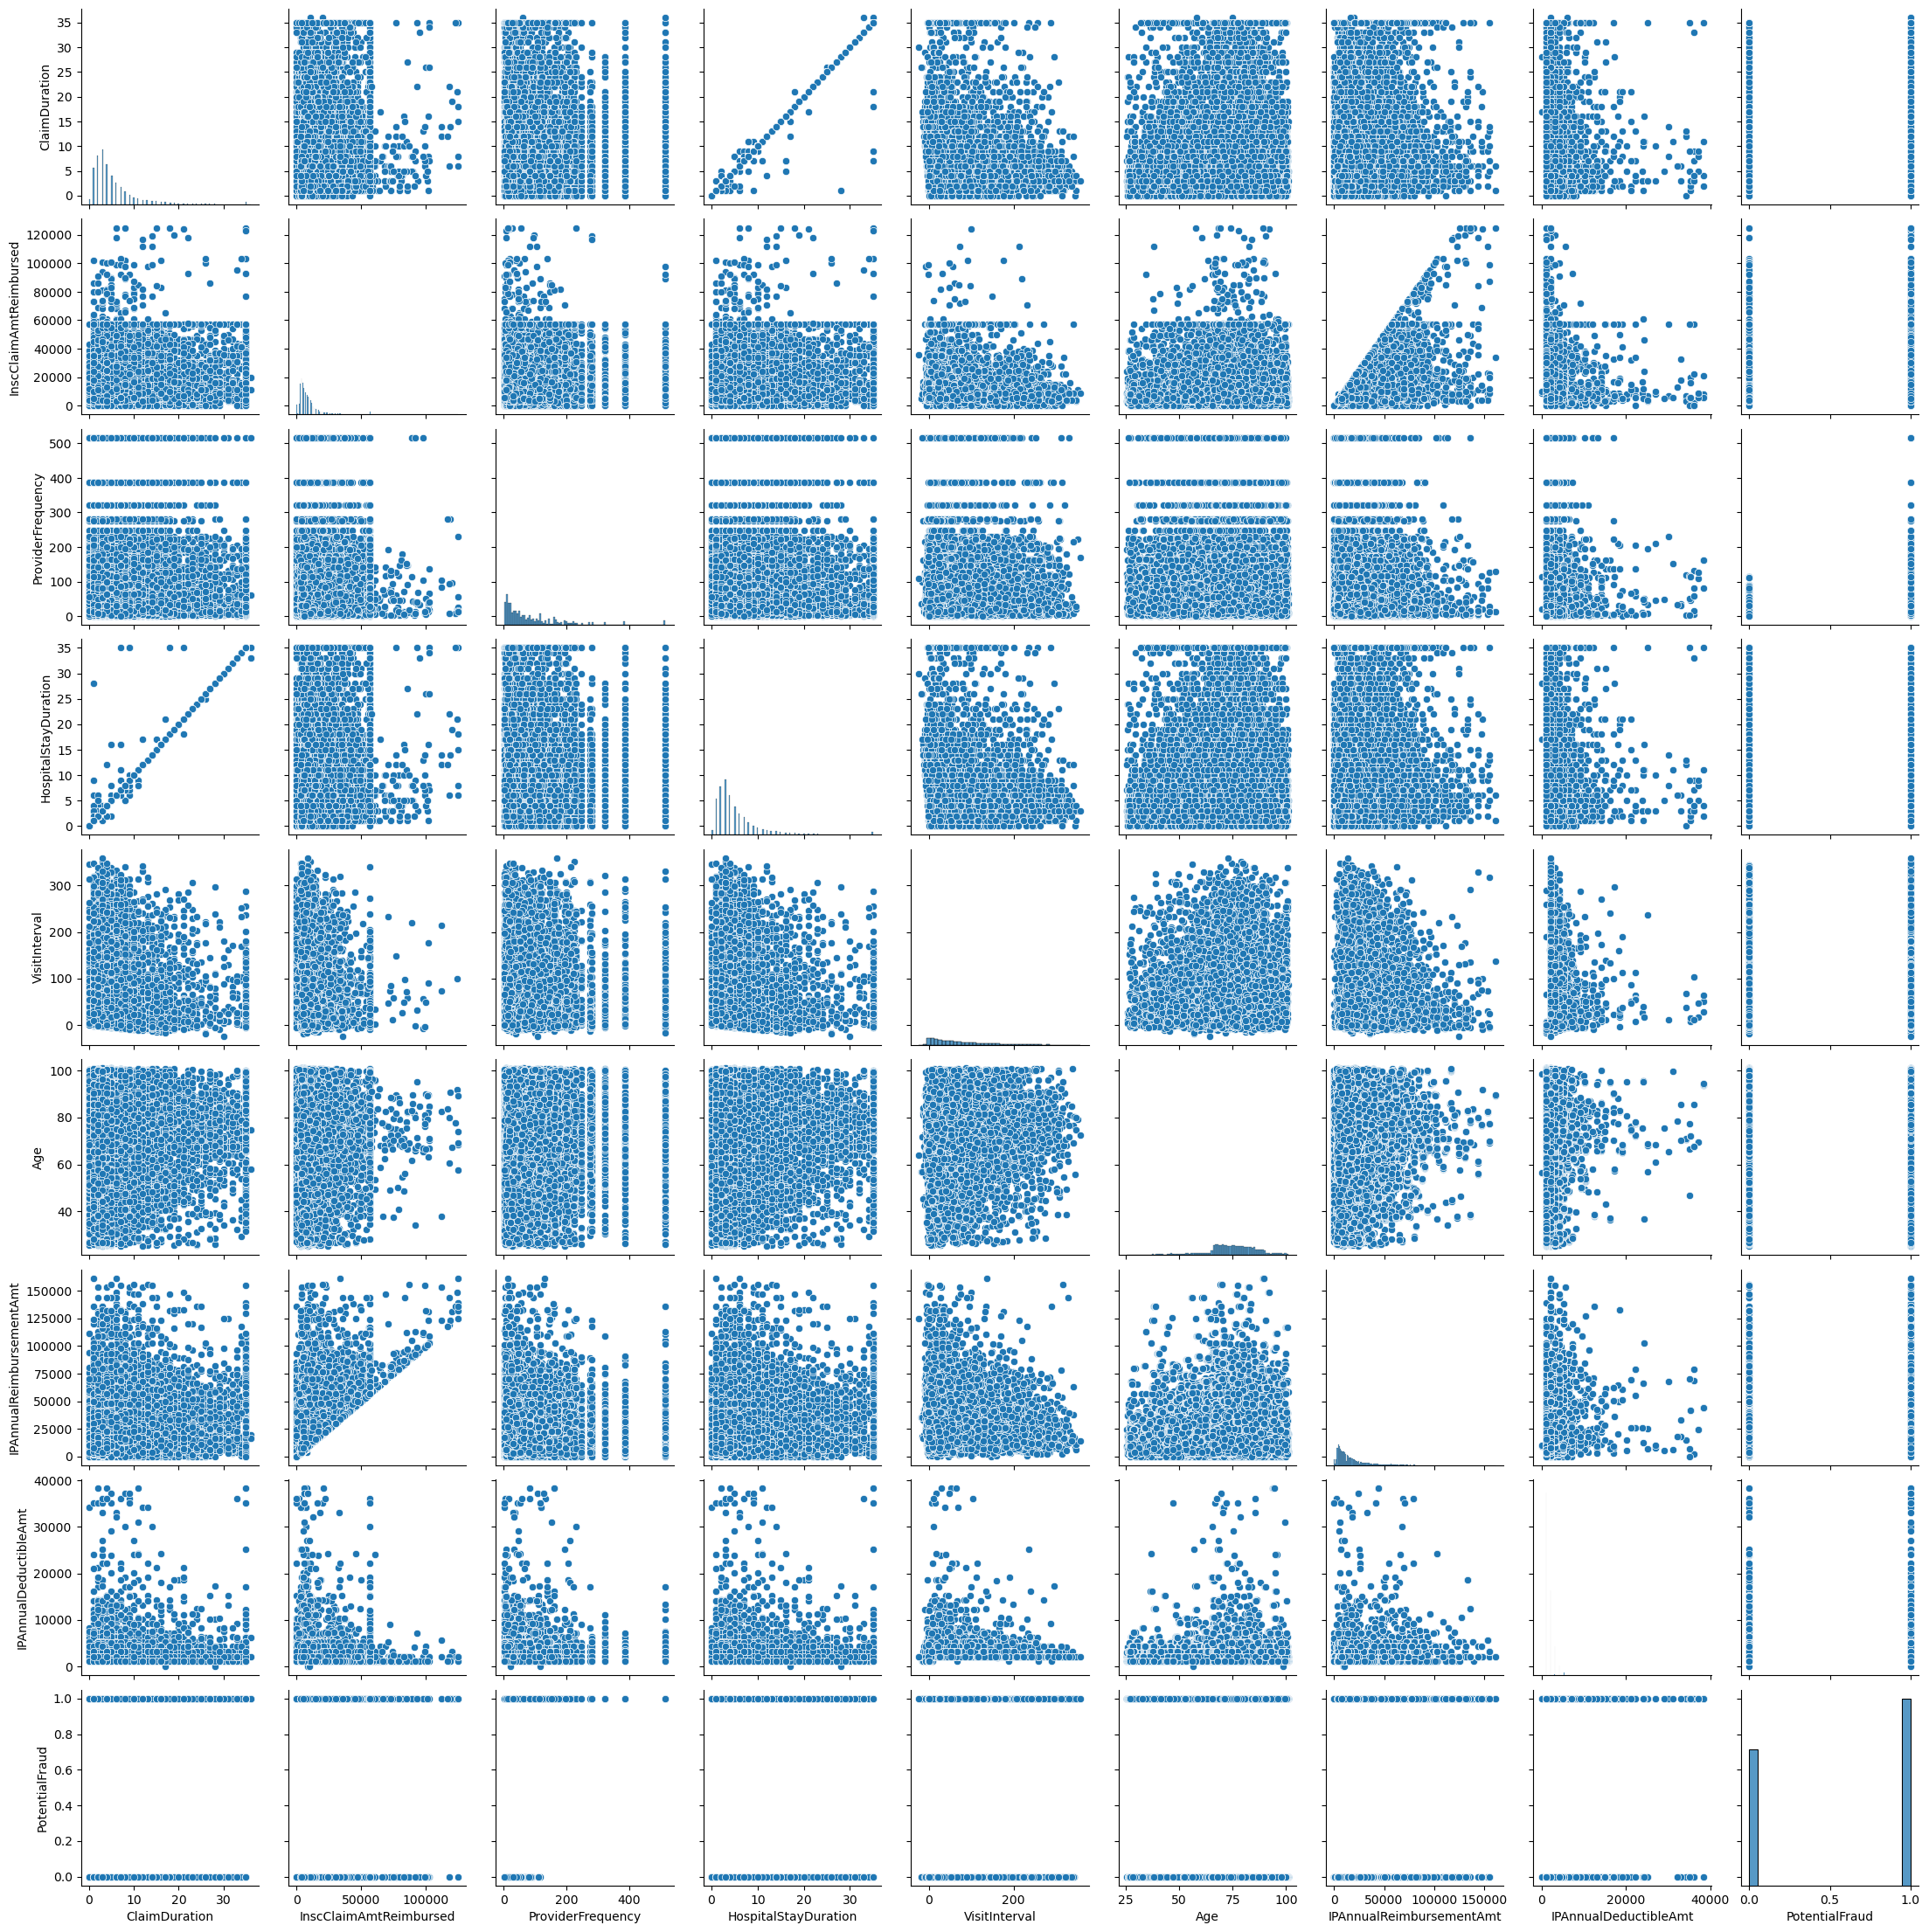

The feature ProviderFrequency exhibits a moderately strong positive linear relationship with the target. Conversely, other features such as ClaimDuration, InscClaimAmtReimbursed, and IPAnnualReimbursementAmt display only a weak correlation. The remaining features appear to have little to no correlation. In an effort to enhance the model's performance, I have opted to incorporate these four numerical features into the training process.


In [65]:
# visualize the confusion matrix and scatter plots
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(numerical_df)
plt.show()

# Observation:
print("The feature ProviderFrequency exhibits a moderately strong positive linear relationship with the target. Conversely, other features such as ClaimDuration, InscClaimAmtReimbursed, and IPAnnualReimbursementAmt display only a weak correlation. The remaining features appear to have little to no correlation. In an effort to enhance the model's performance, I have opted to incorporate these four numerical features into the training process.")

## 3. Model training and Selection

##### (1). Construction of functions for pipelines

In [66]:
# Create a Transformer
class Transformer:
    def __init__(self, df2, df3):
        self.df =None
        self.df2 = df2[["BeneID","IPAnnualReimbursementAmt","State"]]
        self.df3 = df3
        
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame()
        
        df["ClaimID"] = X["ClaimID"]
        df["BeneID"] = X["BeneID"]
        df["Provider"] = X["Provider"]
        
        df["ClaimDuration"] = pd.to_datetime(X["ClaimEndDt"]) - pd.to_datetime(X["ClaimStartDt"])
        df["ClaimDuration"] = df["ClaimDuration"].apply(lambda x:x.days)
        
        df["InscClaimAmtReimbursed"] = X["InscClaimAmtReimbursed"]
        
        df["HasAttendingPhysician"] = X["AttendingPhysician"].notna().astype(int)
        
        df["HasOtherPhysician"] = X["OtherPhysician"].notna().astype(int)
        
        df["AdmitDiagnosticCategory"] = X["ClmAdmitDiagnosisCode"].apply(self.CDC_to_TDC)
        
        df["MajorDiagnosticCategory"] = X["DiagnosisGroupCode"].apply(self.DRG_to_MDC)
        
        df["PrincipalDiagnosticCategory"] = X["ClmDiagnosisCode_1"].apply(self.CDC_to_TDC)
        
        df["PrincipalProcedureCategory"] = X["ClmProcedureCode_1"].apply(self.CPC_to_PPC)
        
        df = pd.merge(df,self.df2, how='left', on='BeneID')
        df = pd.merge(df,self.df3, how='left', on='Provider')
        
        ProviderFrequency = X.groupby(["Provider"]).count()["ClaimID"].reset_index(name = "ProviderFrequency")
        df = pd.merge(df,ProviderFrequency,on="Provider",how="left")
        
        df = df.drop(["ClaimID", "BeneID","Provider","PotentialFraud"], axis=1)
        
        self.df = df
        
        return df

    def fit_transform(self, X, y=None):
        self.fit(X)
        return self.transform(X)
    
    
    def CDC_to_TDC(self,value):
        if pd.isnull(value):return "0"

        # purely numeric
        if value[0] not in ("V","E"):
            # get the first three digit of Claim Diagnosis Code
            first_three_digit = int(value[:3])
            if 1<= first_three_digit <= 9: return "1"
            if 10<= first_three_digit <= 18: return "2"
            if 20<= first_three_digit <= 27: return "3"
            if 30<= first_three_digit <= 41: return "4"
            if 42<= first_three_digit <= 42: return "5"
            if 45<= first_three_digit <= 49: return "6"
            if 50<= first_three_digit <= 59: return "7"
            if 60<= first_three_digit <= 66: return "8"
            if 70<= first_three_digit <= 79: return "9"
            if 80<= first_three_digit <= 88: return "10"
            if 90<= first_three_digit <= 99: return "11"
            if 100<= first_three_digit <= 104: return "12"
            if 110<= first_three_digit <= 118: return "13"
            if 120<= first_three_digit <= 129: return "14"
            if 130<= first_three_digit <= 136: return "15"
            if 137<= first_three_digit <= 139: return "16"
            if 140<= first_three_digit <= 149: return "17"
            if 150<= first_three_digit <= 159: return "18"
            if 160<= first_three_digit <= 165: return "19"
            if 170<= first_three_digit <= 176: return "20"
            if 179<= first_three_digit <= 189: return "21"
            if 190<= first_three_digit <= 199: return "22"
            if 200<= first_three_digit <= 208: return "23"
            if 209<= first_three_digit <= 209: return "24"
            if 210<= first_three_digit <= 229: return "25"
            if 230<= first_three_digit <= 234: return "26"
            if 235<= first_three_digit <= 238: return "27"
            if 239<= first_three_digit <= 239: return "28"
            if 240<= first_three_digit <= 246: return "29"
            if 249<= first_three_digit <= 259: return "30"
            if 260<= first_three_digit <= 269: return "31"
            if 270<= first_three_digit <= 279: return "32"
            if 280<= first_three_digit <= 289: return "33"
            if 290<= first_three_digit <= 294: return "34"
            if 295<= first_three_digit <= 299: return "35"
            if 300<= first_three_digit <= 316: return "36"
            if 317<= first_three_digit <= 319: return "37"
            if 320<= first_three_digit <= 327: return "38"
            if 330<= first_three_digit <= 337: return "39"
            if 338<= first_three_digit <= 338: return "40"
            if 339<= first_three_digit <= 339: return "41"
            if 340<= first_three_digit <= 349: return "42"
            if 350<= first_three_digit <= 359: return "43"
            if 360<= first_three_digit <= 379: return "44"
            if 380<= first_three_digit <= 389: return "45"
            if 390<= first_three_digit <= 392: return "46"
            if 393<= first_three_digit <= 398: return "47"
            if 401<= first_three_digit <= 405: return "48"
            if 410<= first_three_digit <= 414: return "49"
            if 415<= first_three_digit <= 417: return "50"
            if 420<= first_three_digit <= 429: return "51"
            if 430<= first_three_digit <= 438: return "52"
            if 440<= first_three_digit <= 449: return "53"
            if 451<= first_three_digit <= 459: return "54"
            if 460<= first_three_digit <= 466: return "55"
            if 470<= first_three_digit <= 478: return "56"
            if 480<= first_three_digit <= 488: return "57"
            if 490<= first_three_digit <= 496: return "58"
            if 500<= first_three_digit <= 508: return "59"
            if 510<= first_three_digit <= 519: return "60"
            if 520<= first_three_digit <= 529: return "61"
            if 530<= first_three_digit <= 539: return "62"
            if 540<= first_three_digit <= 543: return "63"
            if 550<= first_three_digit <= 553: return "64"
            if 555<= first_three_digit <= 558: return "65"
            if 560<= first_three_digit <= 569: return "66"
            if 570<= first_three_digit <= 579: return "67"
            if 580<= first_three_digit <= 589: return "68"
            if 590<= first_three_digit <= 599: return "69"
            if 600<= first_three_digit <= 608: return "70"
            if 610<= first_three_digit <= 611: return "71"
            if 614<= first_three_digit <= 616: return "72"
            if 617<= first_three_digit <= 629: return "73"
            if 630<= first_three_digit <= 639: return "74"
            if 640<= first_three_digit <= 649: return "75"
            if 650<= first_three_digit <= 659: return "76"
            if 660<= first_three_digit <= 669: return "77"
            if 670<= first_three_digit <= 677: return "78"
            if 678<= first_three_digit <= 679: return "79"
            if 680<= first_three_digit <= 686: return "80"
            if 690<= first_three_digit <= 698: return "81"
            if 700<= first_three_digit <= 709: return "82"
            if 710<= first_three_digit <= 719: return "83"
            if 720<= first_three_digit <= 724: return "84"
            if 725<= first_three_digit <= 729: return "85"
            if 730<= first_three_digit <= 739: return "86"
            if 740<= first_three_digit <= 759: return "87"
            if 760<= first_three_digit <= 763: return "88"
            if 764<= first_three_digit <= 779: return "89"
            if 780<= first_three_digit <= 789: return "90"
            if 790<= first_three_digit <= 796: return "91"
            if 797<= first_three_digit <= 799: return "92"
            if 800<= first_three_digit <= 804: return "93"
            if 805<= first_three_digit <= 809: return "94"
            if 810<= first_three_digit <= 819: return "95"
            if 820<= first_three_digit <= 829: return "96"
            if 830<= first_three_digit <= 839: return "97"
            if 840<= first_three_digit <= 848: return "98"
            if 850<= first_three_digit <= 854: return "99"
            if 860<= first_three_digit <= 869: return "100"
            if 870<= first_three_digit <= 879: return "101"
            if 880<= first_three_digit <= 887: return "102"
            if 890<= first_three_digit <= 897: return "103"
            if 900<= first_three_digit <= 904: return "104"
            if 905<= first_three_digit <= 909: return "105"
            if 910<= first_three_digit <= 919: return "106"
            if 920<= first_three_digit <= 924: return "107"
            if 925<= first_three_digit <= 929: return "108"
            if 930<= first_three_digit <= 939: return "109"
            if 940<= first_three_digit <= 949: return "110"
            if 950<= first_three_digit <= 957: return "111"
            if 958<= first_three_digit <= 959: return "112"
            if 960<= first_three_digit <= 979: return "113"
            if 980<= first_three_digit <= 989: return "114"
            if 990<= first_three_digit <= 995: return "115"
            if 996<= first_three_digit <= 999: return "116"

        # code beginning with E  
        elif value[0] == "E":
            # get the first three digit of Claim Diagnosis Code
            first_three_digit = int(value[1:4])
            if 0<= first_three_digit <= 0: return "133"
            if 1<= first_three_digit <= 30: return "134"
            if 800<= first_three_digit <= 807: return "135"
            if 810<= first_three_digit <= 819: return "136"
            if 820<= first_three_digit <= 825: return "137"
            if 826<= first_three_digit <= 829: return "138"
            if 830<= first_three_digit <= 838: return "139"
            if 840<= first_three_digit <= 845: return "140"
            if 846<= first_three_digit <= 849: return "141"
            if 850<= first_three_digit <= 858: return "142"
            if 860<= first_three_digit <= 869: return "143"
            if 870<= first_three_digit <= 876: return "144"
            if 878<= first_three_digit <= 879: return "145"
            if 880<= first_three_digit <= 888: return "146"
            if 890<= first_three_digit <= 899: return "147"
            if 900<= first_three_digit <= 909: return "148"
            if 910<= first_three_digit <= 915: return "149"
            if 916<= first_three_digit <= 928: return "150"
            if 929<= first_three_digit <= 929: return "151"
            if 930<= first_three_digit <= 949: return "152"
            if 950<= first_three_digit <= 959: return "153"
            if 960<= first_three_digit <= 969: return "154"
            if 970<= first_three_digit <= 978: return "155"
            if 980<= first_three_digit <= 989: return "156"
            if 990<= first_three_digit <= 999: return "157"

        # code beginning with V
        elif value[0] == "V":
            # get the first two digit of Claim Diagnosis Code
            first_two_digit = int(value[1:3])
            if 1 <= first_two_digit <= 9: return "117"
            if 10 <= first_two_digit <= 19: return "118"
            if 20 <= first_two_digit <= 29: return "119"
            if 30 <= first_two_digit <= 39: return "120"
            if 40 <= first_two_digit <= 49: return "121"
            if 50 <= first_two_digit <= 59: return "122"
            if 60 <= first_two_digit <= 69: return "123"
            if 70 <= first_two_digit <= 82: return "124"
            if 83 <= first_two_digit <= 84: return "125"
            if 85 <= first_two_digit <= 85: return "126"
            if 86 <= first_two_digit <= 86: return "127"
            if 87 <= first_two_digit <= 87: return "128"
            if 88 <= first_two_digit <= 88: return "129"
            if 89 <= first_two_digit <= 89: return "130"
            if 90 <= first_two_digit <= 90: return "131"
            if 91 <= first_two_digit <= 91: return "132"
        
        return "999"
    
    def DRG_to_MDC(self,value):
        if value == "OTH": return "99"
        
        numeric_value = int(value)
        
        if 1 <= numeric_value <= 17: return "0"
        if 20 <= numeric_value <= 103: return "1"
        if 113 <= numeric_value <= 125: return "2"
        if 129 <= numeric_value <= 159: return "3"
        if 163 <= numeric_value <= 208: return "4"
        if 215 <= numeric_value <= 316: return "5"
        if 326 <= numeric_value <= 395: return "6"
        if 405 <= numeric_value <= 446: return "7"
        if 453 <= numeric_value <= 566: return "8"
        if 573 <= numeric_value <= 607: return "9"
        if 614 <= numeric_value <= 645: return "10"
        if 652 <= numeric_value <= 700: return "11"
        if 707 <= numeric_value <= 730: return "12"
        if 734 <= numeric_value <= 761: return "13"
        if 765 <= numeric_value <= 782: return "14"
        if 789 <= numeric_value <= 795: return "15"
        if 799 <= numeric_value <= 816: return "16"
        if 820 <= numeric_value <= 849: return "17"
        if 853 <= numeric_value <= 872: return "18"
        if 876 <= numeric_value <= 887: return "19"
        if 894 <= numeric_value <= 897: return "20"
        if 901 <= numeric_value <= 923: return "21"
        if 927 <= numeric_value <= 935: return "22"
        if 939 <= numeric_value <= 951: return "23"
        if 955 <= numeric_value <= 965: return "24"
        if 969 <= numeric_value <= 977: return "25"
        if 981 <= numeric_value <= 999: return "26"
    
    def CPC_to_PPC(self,value):
    # handle the missing values
        if pd.isnull(value): return "99"

        # the Claim Procedure Code less than 100 must start with "00"
        if value < 100: return "0"

        # get the first two digits of Claim Procedure Code
        first_two_digit = int(str(value)[:2])
        if 1 <= first_two_digit <= 5: return "1"
        if 6 <= first_two_digit <= 7: return "2"
        if 8 <= first_two_digit <= 16: return "3"
        if 17 <= first_two_digit <= 17: return "3A"
        if 18 <= first_two_digit <= 20: return "4"
        if 21 <= first_two_digit <= 29: return "5"
        if 30 <= first_two_digit <= 34: return "6"
        if 35 <= first_two_digit <= 39: return "7"
        if 40 <= first_two_digit <= 41: return "8"
        if 42 <= first_two_digit <= 54: return "9"
        if 55 <= first_two_digit <= 59: return "10"
        if 60 <= first_two_digit <= 64: return "11"
        if 65 <= first_two_digit <= 71: return "12"
        if 72 <= first_two_digit <= 75: return "13"
        if 76 <= first_two_digit <= 84: return "14"
        if 85 <= first_two_digit <= 86: return "15"
        if 87 <= first_two_digit <= 99: return "16"

        return "99"
    
    def get_feature_names_out(self, input_features=None):
        # Generate the list of output feature names
        output_feature_names = self.df.columns
        return output_feature_names


In [67]:
# load the original data
df_label = pd.read_csv(".\kaggle_data\Train-1542865627584.csv")
df_bene = pd.read_csv(".\kaggle_data\Train_Beneficiarydata-1542865627584.csv")
df_inp = pd.read_csv(".\kaggle_data\Train_Inpatientdata-1542865627584.csv")
df_outp = pd.read_csv(".\kaggle_data\Train_Outpatientdata-1542865627584.csv")

transformer = Transformer(df_bene, df_label)
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')

##### (2). Creation of training and testing sets.

In [68]:
# Define key features for model training after EDA
numerical_features = ['HasAttendingPhysician',  'HasOtherPhysician', 'ClaimDuration', 'ProviderFrequency','InscClaimAmtReimbursed', 'IPAnnualReimbursementAmt']
categorical_features = ['AdmitDiagnosticCategory', 'MajorDiagnosticCategory',  'PrincipalDiagnosticCategory',  'PrincipalProcedureCategory',  'State']
key="Provider"
target = "PotentialFraud"

# Create a function to derive training and testing sets
def create_training_testing_set(df_primary,df_label,key,target,test_size,random_state):
    df_label[target] = df_label[target].apply(lambda x:1 if x=="Yes" or x==1 else 0)
    
    X_train, X_test, y_train, y_test = train_test_split(df_label, df_label,test_size=test_size,random_state=random_state)
    
    df_train_merge = pd.merge(df_primary, X_train, on = key , how ="inner")
    df_test_merge = pd.merge(df_primary, X_test, on = key , how ="inner")
    
    X_train = df_train_merge
    y_train = df_train_merge[target]
    
    X_test = df_test_merge
    y_test = df_test_merge[target]

    return X_train, X_test, y_train, y_test

# create the training and testing set
X_train, X_test, y_train, y_test = create_training_testing_set(df_inp,df_label,key,target,0.2,66)

##### (3). Model Training and Fine-tuning

In [69]:
# fine-tune the model
xgb_pipe = Pipeline(
            steps=[
            ('custom_transform', transformer),
            ('preprocessor', ColumnTransformer(transformers = [('categorical', one_hot_encoder, categorical_features)],
                                               remainder = 'passthrough')),
            ('xgb', XGBClassifier())])

param = {
        'xgb__n_estimators': [50, 100],  # 
        'xgb__learning_rate': [0.15, 0.25, 0.35],  
        'xgb__reg_alpha': [ 500, 700, 1000],
        'xgb__reg_lambda': [50, 100] ,    
        'xgb__max_depth': [2, 3, 5]  
        }
    
cv = KFold(n_splits=3, shuffle=True, random_state=66)

xgb_cv1 = GridSearchCV(xgb_pipe, param_grid=param, cv=cv, scoring="f1")
xgb_cv1.fit(X_train,y_train)

print("Best parameter for XGBoost:", xgb_cv1.best_params_)

rf_pipe = Pipeline(
            steps=[
            ('custom_transform', transformer),
            ('preprocessor', ColumnTransformer(transformers = [('categorical', one_hot_encoder, categorical_features)],
                                               remainder = 'passthrough')),
            ('rf', RandomForestClassifier())])

param = {
        'rf__n_estimators': [50, 100 ],     
        'rf__max_depth': [50, 100, 150 ],  
        'rf__max_features': [ 1, 5, 10],
        'rf__min_samples_leaf': [5, 10, 20]
        }
    
rf_cv1 = GridSearchCV(rf_pipe, param_grid=param, cv=cv, scoring="f1")
rf_cv1.fit(X_train,y_train)

print("Best parameter for Random Forest:", rf_cv1.best_params_)

Best parameter for XGBoost: {'xgb__learning_rate': 0.35, 'xgb__max_depth': 5, 'xgb__n_estimators': 50, 'xgb__reg_alpha': 700, 'xgb__reg_lambda': 50}
Best parameter for Random Forest: {'rf__max_depth': 50, 'rf__max_features': 5, 'rf__min_samples_leaf': 20, 'rf__n_estimators': 100}


In [70]:
# train the XGBoost model with optimal hyperparmaters
xgb_pipe = Pipeline(
            steps=[
            ('custom_transform', transformer),
            ('preprocessor', ColumnTransformer(transformers = [('categorical', one_hot_encoder, categorical_features)],
                                               remainder = 'passthrough')),
            ('xgb', XGBClassifier(learning_rate = xgb_cv1.best_params_['xgb__learning_rate'],
                                  max_depth = xgb_cv1.best_params_['xgb__max_depth'],
                                  n_estimators = xgb_cv1.best_params_['xgb__n_estimators'],
                                  reg_alpha = xgb_cv1.best_params_['xgb__reg_alpha'],
                                  reg_lambda = xgb_cv1.best_params_['xgb__reg_lambda']))]
                           )

# Fit the pipeline to your training data and count the running time
start  = time.time()
xgb_model = xgb_pipe.fit(X_train, y_train)
end = time.time()
xgb_runing_time = end - start


# train the Random Forest model with optimal hyperparmaters
rf_pipe = Pipeline(
            steps=[
            ('custom_transform', transformer),
            ('preprocessor', ColumnTransformer(transformers = [('categorical', one_hot_encoder, categorical_features)],
                                               remainder = 'passthrough')),
            ('rf', RandomForestClassifier(n_estimators = rf_cv1.best_params_['rf__n_estimators'],
                                          max_depth = rf_cv1.best_params_['rf__max_depth'],
                                          min_samples_leaf = rf_cv1.best_params_['rf__min_samples_leaf'],
                                          max_features = rf_cv1.best_params_['rf__max_features']
                                            ))]
                           )

# Fit the pipeline to your training data
start  = time.time()
rf_model = rf_pipe.fit(X_train, y_train)
end = time.time()
rf_runing_time = end - start

##### (4). Performance Analysis and Model Selection

Running time of XGBoost Model: 0.5481500625610352
Report_train: 
              precision    recall  f1-score   support

           0       0.80      0.68      0.74     13736
           1       0.79      0.88      0.83     19033

    accuracy                           0.79     32769
   macro avg       0.80      0.78      0.78     32769
weighted avg       0.80      0.79      0.79     32769

Report_test: 
              precision    recall  f1-score   support

           0       0.82      0.67      0.73      3336
           1       0.78      0.89      0.83      4369

    accuracy                           0.79      7705
   macro avg       0.80      0.78      0.78      7705
weighted avg       0.79      0.79      0.79      7705



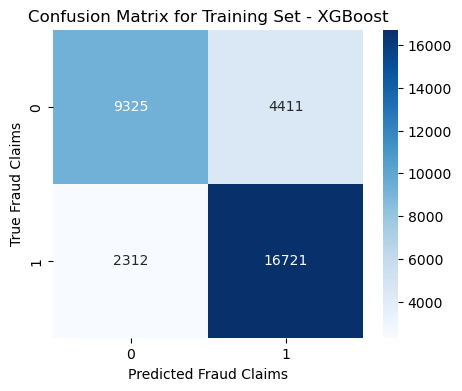

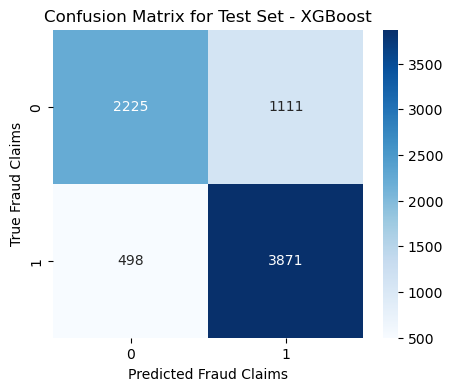

In [71]:
# derive the predicted outcomes
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# output the performance metrics
report_train_xgb = classification_report(y_train, y_train_pred_xgb)
report_test_xgb = classification_report(y_test, y_test_pred_xgb)

print("Running time of XGBoost Model:",xgb_runing_time)
print("Report_train: ")
print(report_train_xgb)
print("Report_test: ")
print(report_test_xgb)

cm_train_xgb = confusion_matrix(y_train, y_train_pred_xgb)
cm_test_xgb = confusion_matrix(y_test, y_test_pred_xgb)

# For the training set
plt.figure(figsize=(5, 4))
sns.heatmap(cm_train_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Training Set - XGBoost')
plt.xlabel('Predicted Fraud Claims')
plt.ylabel('True Fraud Claims')
plt.show()

# For the test set
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Test Set - XGBoost')
plt.xlabel('Predicted Fraud Claims')
plt.ylabel('True Fraud Claims')
plt.show()

Running time of Random Forest Model: 1.988184928894043
Report_train: 
              precision    recall  f1-score   support

           0       0.79      0.56      0.65     13736
           1       0.74      0.89      0.81     19033

    accuracy                           0.75     32769
   macro avg       0.76      0.72      0.73     32769
weighted avg       0.76      0.75      0.74     32769

Report_test: 
              precision    recall  f1-score   support

           0       0.75      0.49      0.59      3336
           1       0.69      0.87      0.77      4369

    accuracy                           0.71      7705
   macro avg       0.72      0.68      0.68      7705
weighted avg       0.72      0.71      0.70      7705



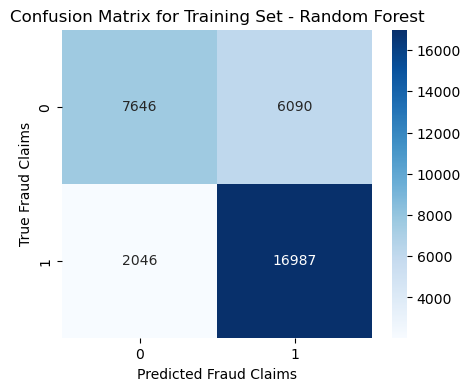

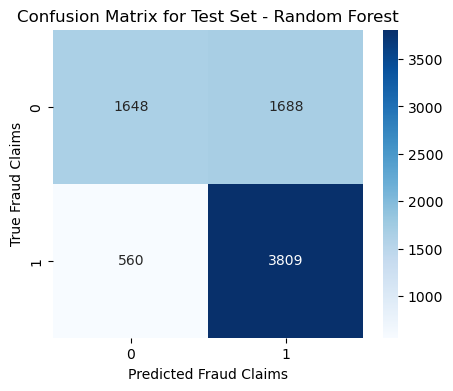

In [72]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

report_train_rf = classification_report(y_train, y_train_pred_rf)
report_test_rf = classification_report(y_test, y_test_pred_rf)

print("Running time of Random Forest Model:",rf_runing_time)
print("Report_train: ")
print(report_train_rf)
print("Report_test: ")
print(report_test_rf)

cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)

# For the training set
plt.figure(figsize=(5, 4))
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Training Set - Random Forest')
plt.xlabel('Predicted Fraud Claims')
plt.ylabel('True Fraud Claims')
plt.show()

# For the test set
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Test Set - Random Forest')
plt.xlabel('Predicted Fraud Claims')
plt.ylabel('True Fraud Claims')
plt.show()

In [73]:
# choose the final model
final_model = xgb_model["xgb"]
print("The performance of models with XGBoost and Random Forest is similar. I would like to choose XGBoost model since it has better efficiency.")

The performance of models with XGBoost and Random Forest is similar. I would like to choose XGBoost model since it has better efficiency.


## 5. Model Interpretation

[18:25:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


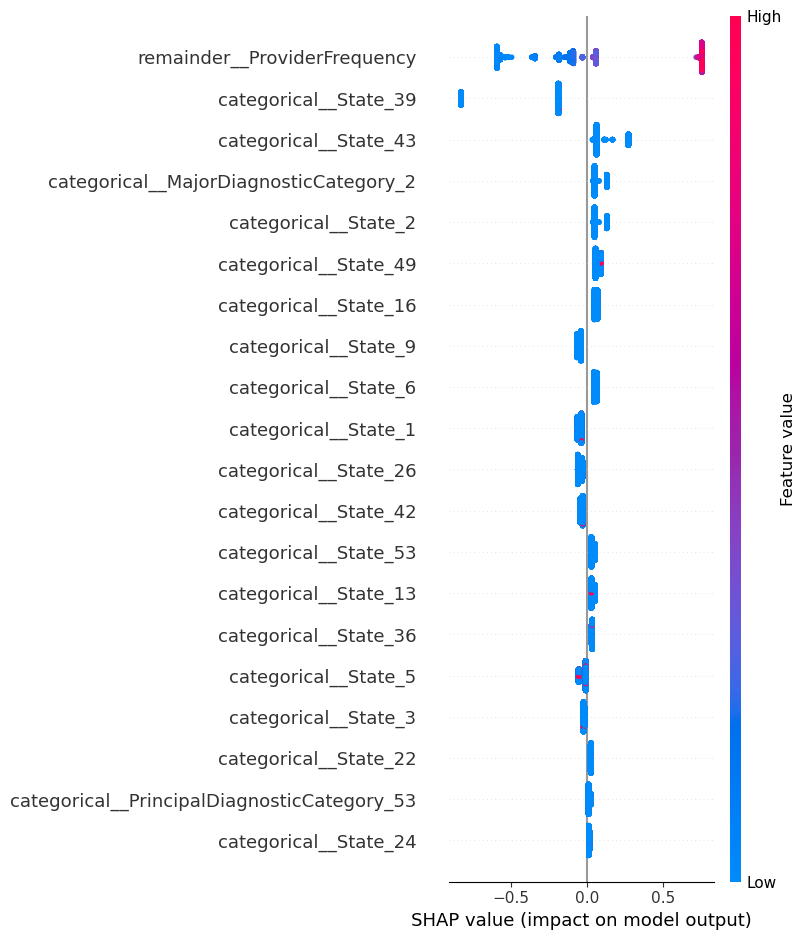

The most impactful features are ProviderFrequency, State and MajorDiagnosticCategory.
Examine the attributes of Provider, State, and DiagnosisGroupCode in the claims record carefully.


In [74]:
# Extract the model and preprocessing part of the pipeline
preprocess_pipeline = Pipeline(xgb_pipe.steps[:-1])

# Transform the test data
X_test_transform = preprocess_pipeline.transform(X_test)
X_test_transform = X_test_transform.toarray()

# Calculate SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_transform)

# Output the final feature names from the transformer
transformed_feature_names = list(preprocess_pipeline.get_feature_names_out())

# Summarize the effects of features
shap.summary_plot(shap_values, X_test_transform, feature_names=transformed_feature_names)

# Observation:
print("The most impactful features are ProviderFrequency, State and MajorDiagnosticCategory.")

# Actionable suggestions:
print("Examine the attributes of Provider, State, and DiagnosisGroupCode in the claims record carefully.")

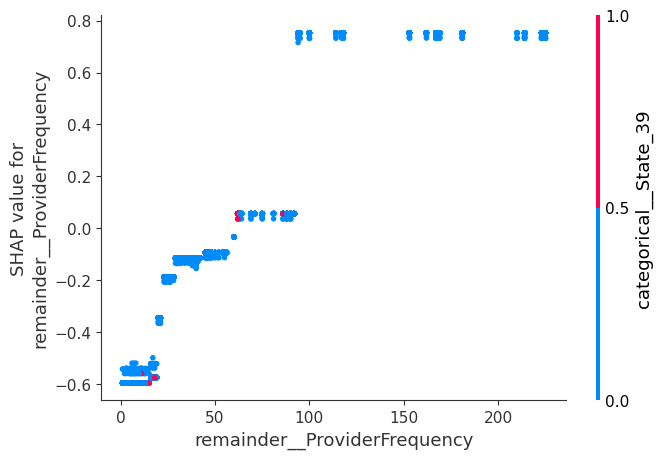

When the ProviderFrequency exceeds 60, it begins to positively affect the detection of fraud claims.
Focus increased scrutiny on claims from Providers with over 60 claim records in a single year.


In [75]:
# Find the index of the relevant features
feature_index = transformed_feature_names.index('remainder__ProviderFrequency')
interaction_index = transformed_feature_names.index('categorical__State_39')

# Use the index for the SHAP dependence plot
shap.dependence_plot(feature_index, shap_values, X_test_transform, interaction_index=interaction_index, feature_names=transformed_feature_names)

# Observation:
print("When the ProviderFrequency exceeds 60, it begins to positively affect the detection of fraud claims.")

# Actionable suggestions:
print("Focus increased scrutiny on claims from Providers with over 60 claim records in a single year.")

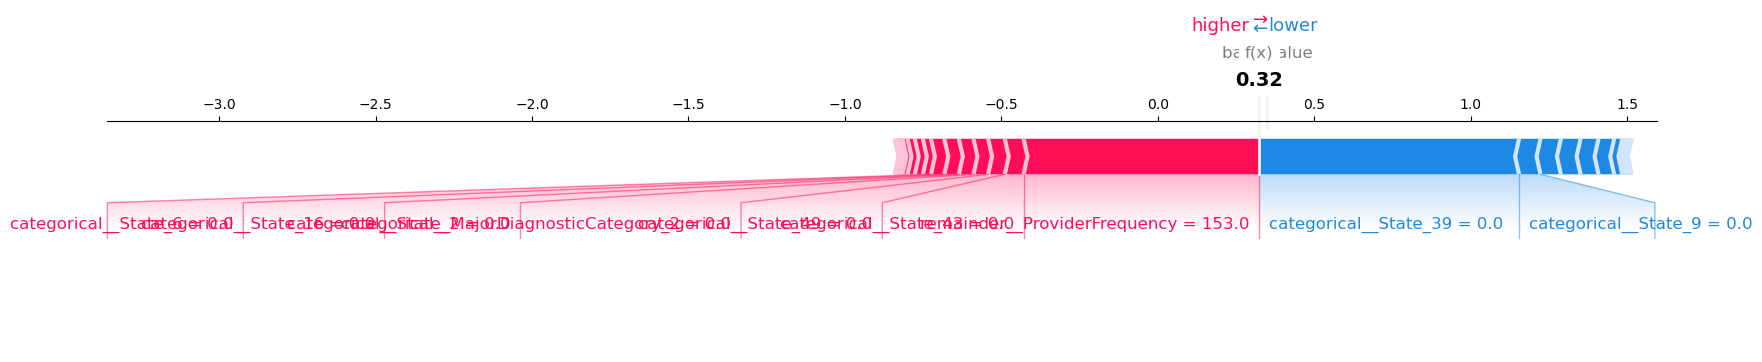

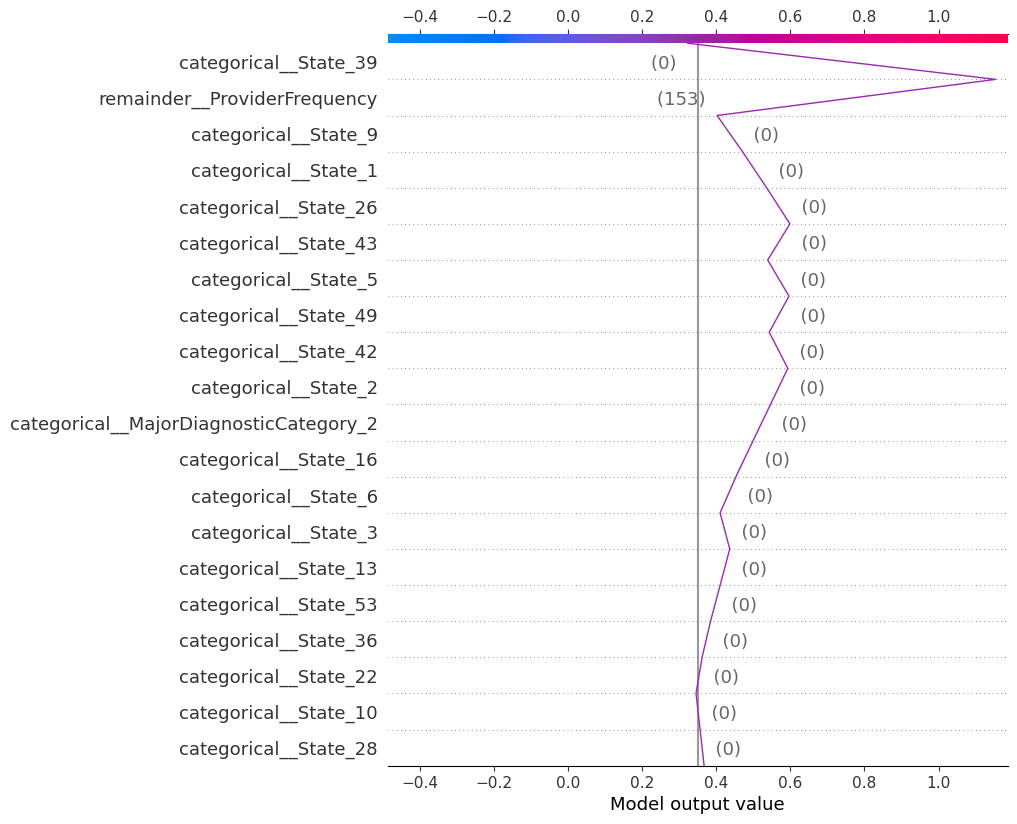

For the instance at index 0, which is a positive classification, the ProviderFrequency and the claim's State being 39 are the primary influencers on the model's decision.


In [76]:
# Case study - positive case
# Use the index for the force plot
index = 0
shap.plots.force(explainer.expected_value, shap_values[index], X_test_transform[index], feature_names=transformed_feature_names, matplotlib = True)

# Use the index for the decision plot
shap.decision_plot(explainer.expected_value, shap_values[index], X_test_transform[index], feature_names=transformed_feature_names)

# Observation:
print("For the instance at index 0, which is a positive classification, the ProviderFrequency and the claim's State being 39 are the primary influencers on the model's decision.")

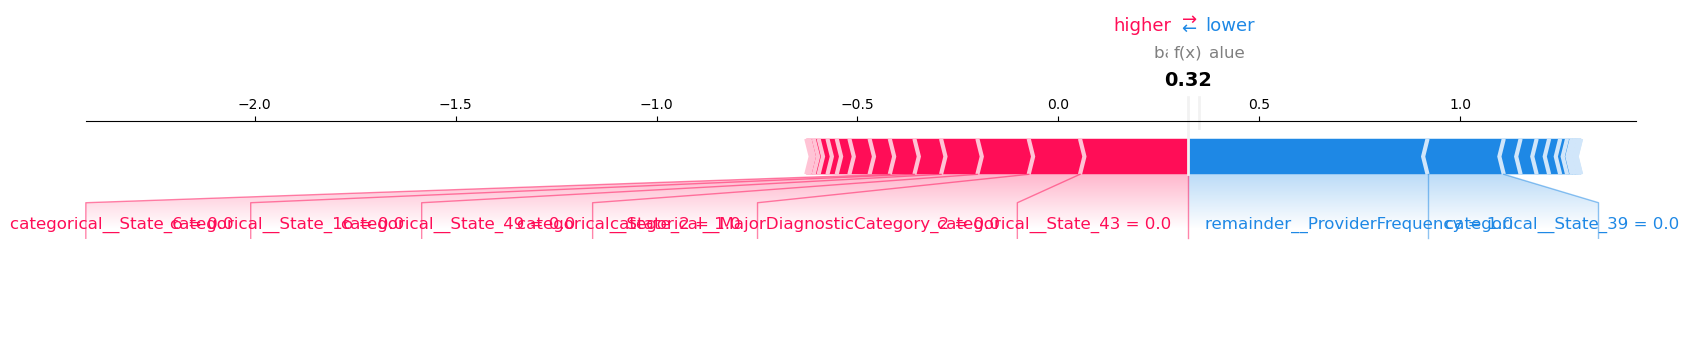

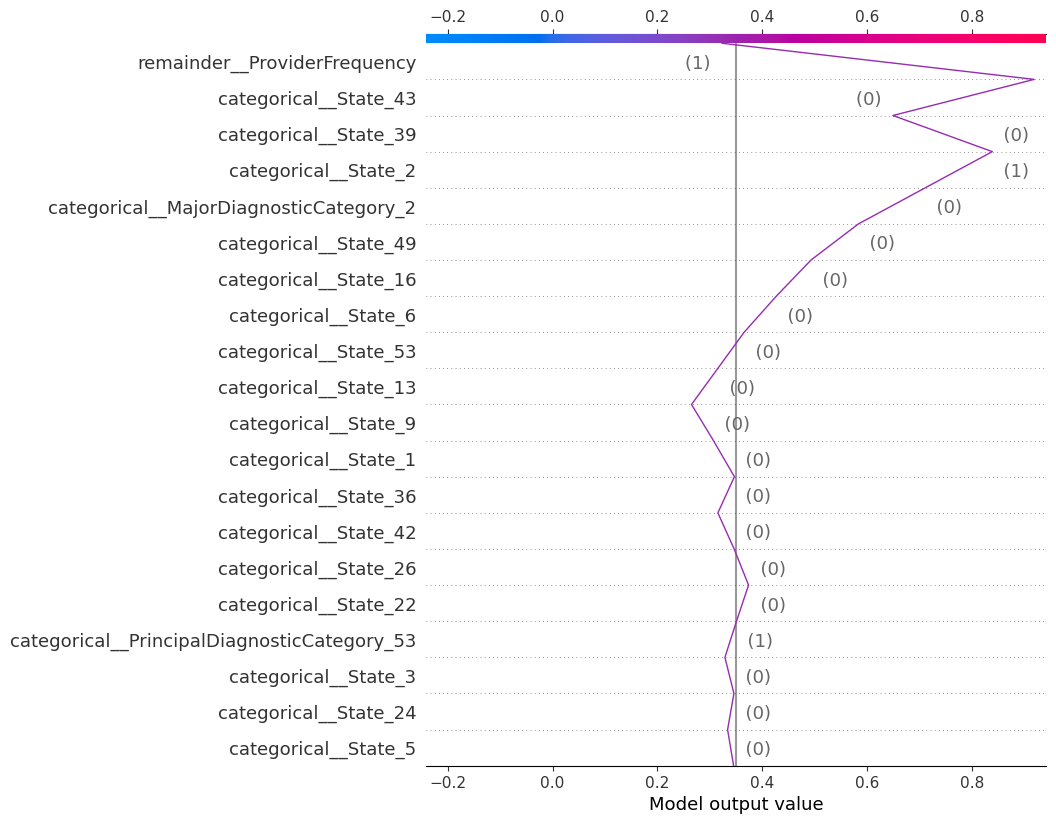

For the instance at index 7700, which is a negative classification, the ProviderFrequency and the claim's State being 43 are the primary influencers on the model's decision.


In [77]:
# Case study - negative case
# Use the index for the force plot
index = 7700
shap.plots.force(explainer.expected_value, shap_values[index], X_test_transform[index], feature_names=transformed_feature_names, matplotlib = True)

# Use the index for the decision plot
shap.decision_plot(explainer.expected_value, shap_values[index], X_test_transform[index], feature_names=transformed_feature_names)

# Observation:
print("For the instance at index 7700, which is a negative classification, the ProviderFrequency and the claim's State being 43 are the primary influencers on the model's decision.")